# Imports 

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import GradientBoostingRegressor, VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.holtwinters import ExponentialSmoothing
import seaborn as sns

In [11]:

df = pd.read_csv("skyscanner_airfare_data.csv")

df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")

df = df.dropna(
    subset=[
        "Revenue",
        "FlightWeek",
        "MainAirlineCarrier",
    ]
).copy()

df["WeekNumber"] = (
    df["FlightWeek"]
    .astype(str)
    .str.extract(r"W(\d+)")
    .astype(int)
)

df["Route"] = (
    df["OriginAirport"].astype(str)
    + "_"
    + df["DestinationAirport"].astype(str)
)

df["CountryRoute"] = (
    df["OriginCountry"].astype(str)
    + "_"
    + df["DestinationCountry"].astype(str)
)

df["WeekSin"] = np.sin(2 * np.pi * df["WeekNumber"] / 52)
df["WeekCos"] = np.cos(2 * np.pi * df["WeekNumber"] / 52)

df["LogRevenue"] = np.log1p(df["Revenue"])

numeric_cols_to_clean = [
    "IsConnectingFlight",
    "NumberOfNights",
    "BookingHorizon",
]

for col in numeric_cols_to_clean:
    if col in df.columns:
        if col == "IsConnectingFlight":
            s = df[col]

            if s.dtype == bool:
                df[col] = s.astype(int)
            else:
                map_values = {
                    "true": 1,
                    "false": 0,
                    "yes": 1,
                    "no": 0,
                    "1": 1,
                    "0": 0,
                }

                mapped = s.astype(str).str.lower().map(map_values)
                numeric = pd.to_numeric(s, errors="coerce")

                df[col] = (
                    mapped
                    .fillna(numeric)
                    .fillna(0)
                    .astype(int)
                )
        else:
            df[col] = pd.to_numeric(df[col], errors="coerce")
df.head(2)

,FlightWeek,OriginAirport,OriginCountry,DestinationAirport,DestinationCountry,MainAirlineCarrier,IsConnectingFlight,UserCountry,TripType,CabinClass,NumberOfNights,BookingHorizon,NumberOfRedirects,Revenue,WeekNumber,Route,CountryRoute,WeekSin,WeekCos,LogRevenue
0,2024-W01,AMS,NL,AGP,ES,LH,0,CZ,one-way,Economy,14,68,4,84.67,1,AMS_AGP,NL_ES,0.120537,0.992709,4.450503
1,2024-W01,AMS,NL,AYT,TR,FR,0,BE,round-trip,Economy,16,33,4,30.99,1,AMS_AYT,NL_TR,0.120537,0.992709,3.465423


In [14]:
df = df[df["MainAirlineCarrier"] != "EW"].copy()

# Exploratory Data Analysis

We will be plotting the graph to see whats the distribution of our features are etc

EDA rows: 55000
Weeks: 1 to 52


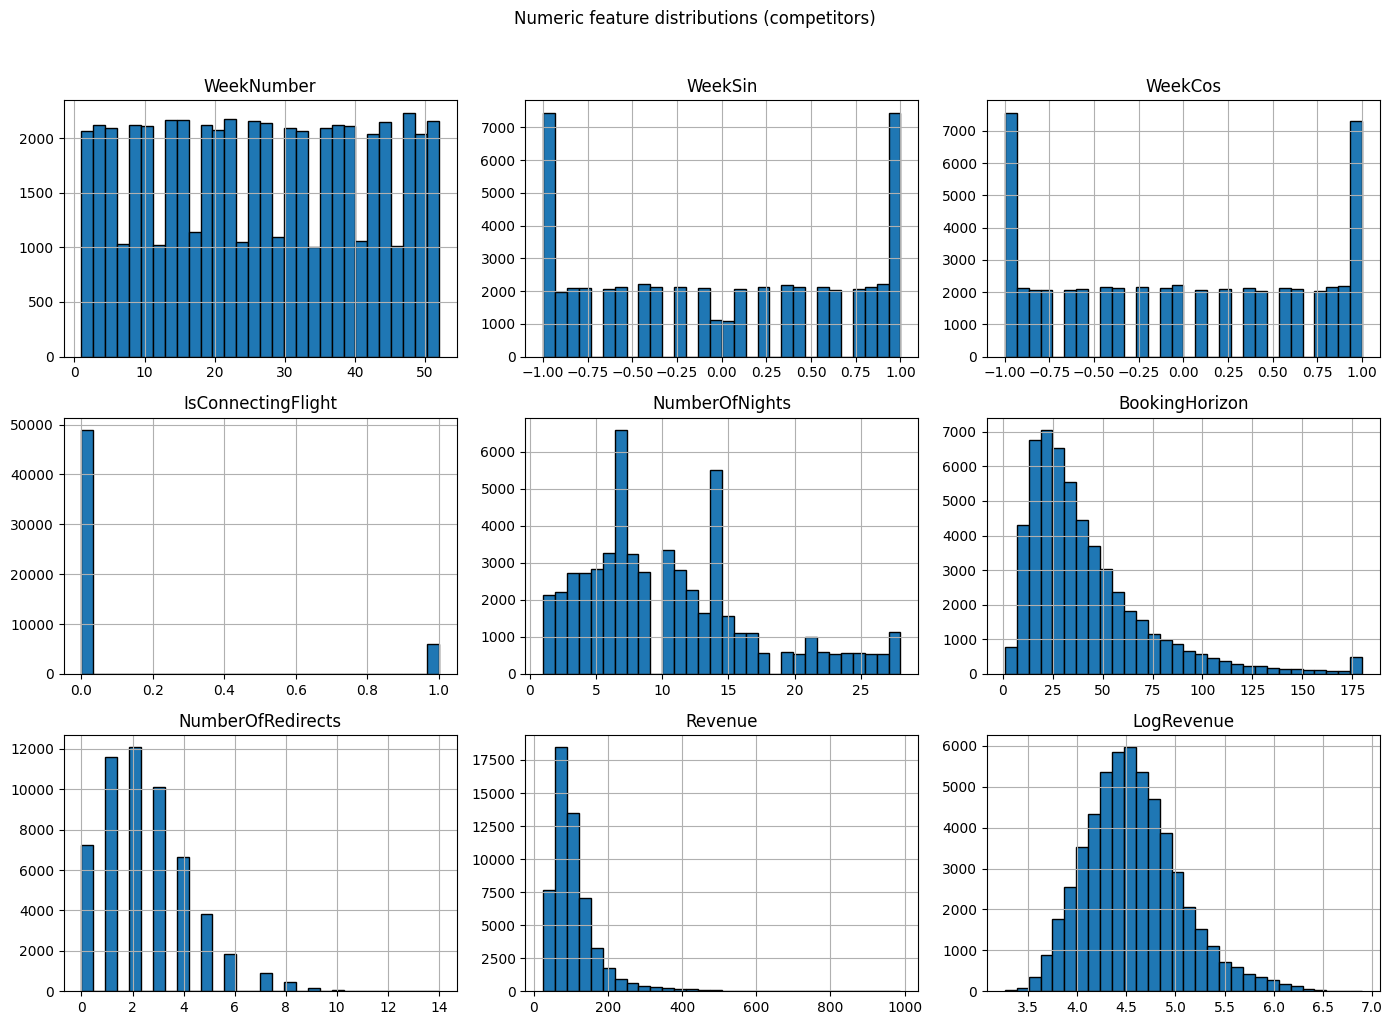

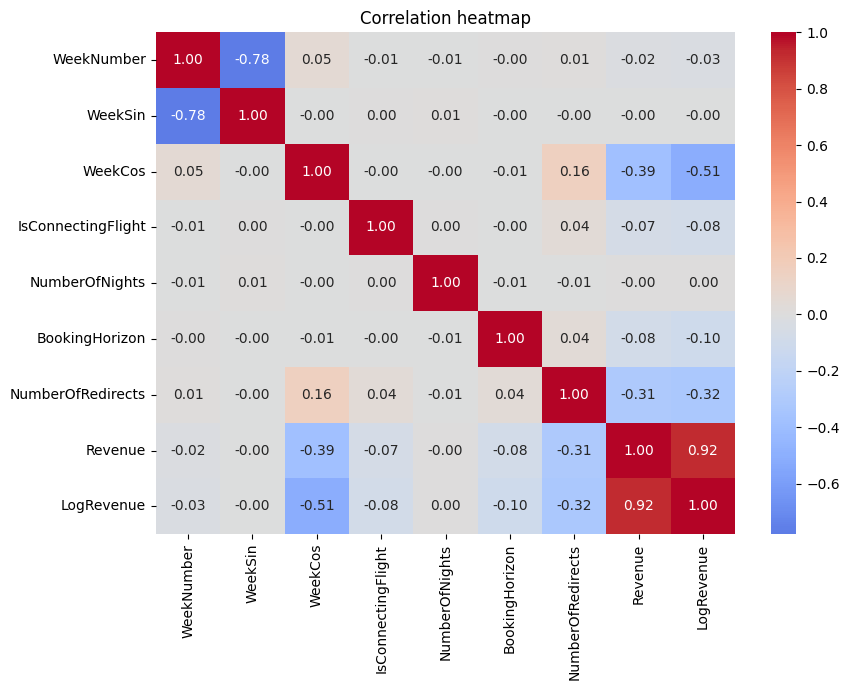

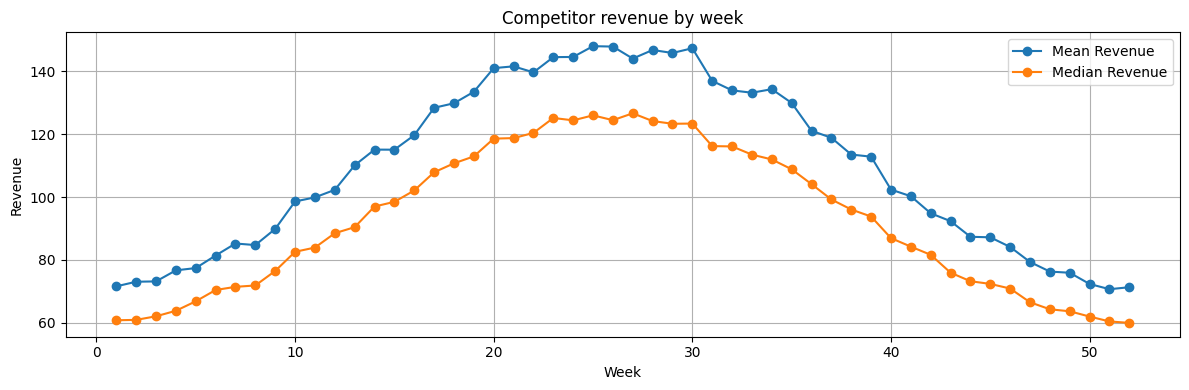

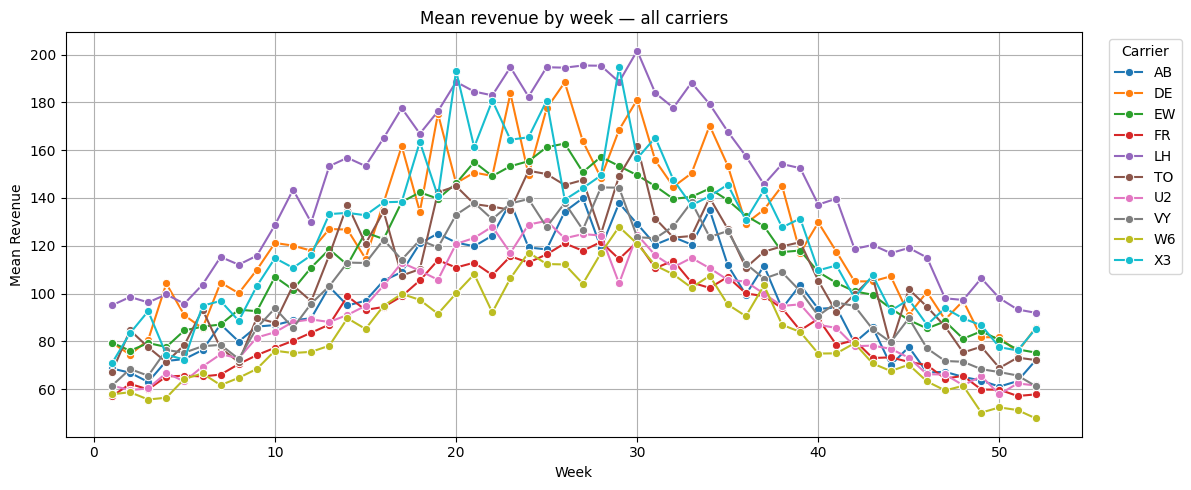

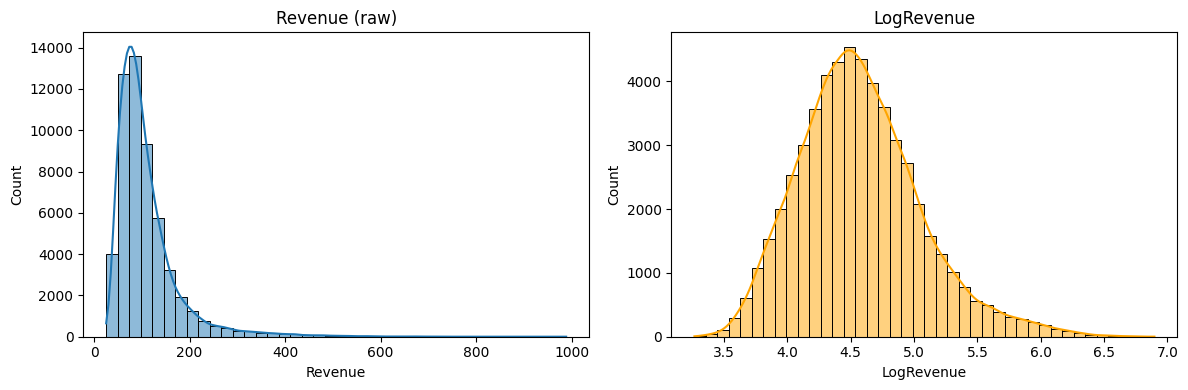

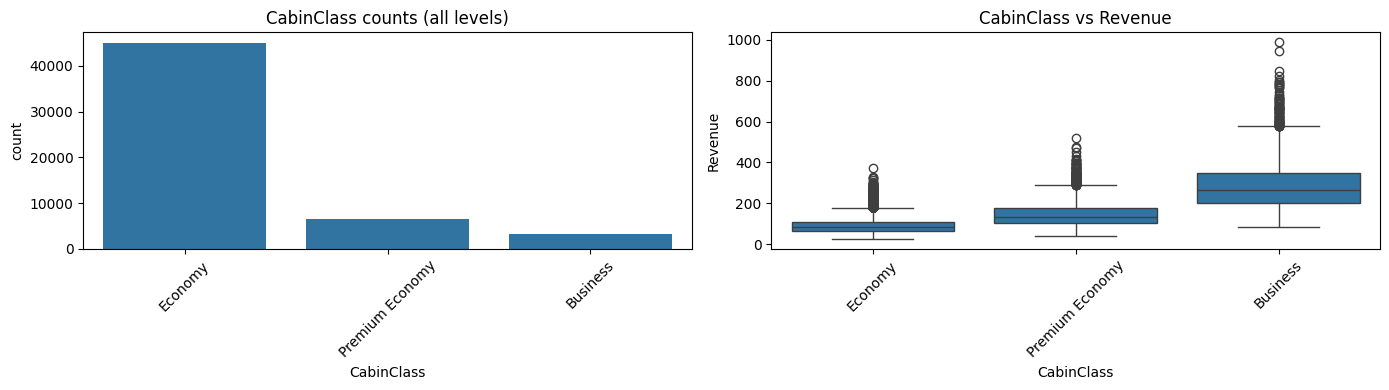

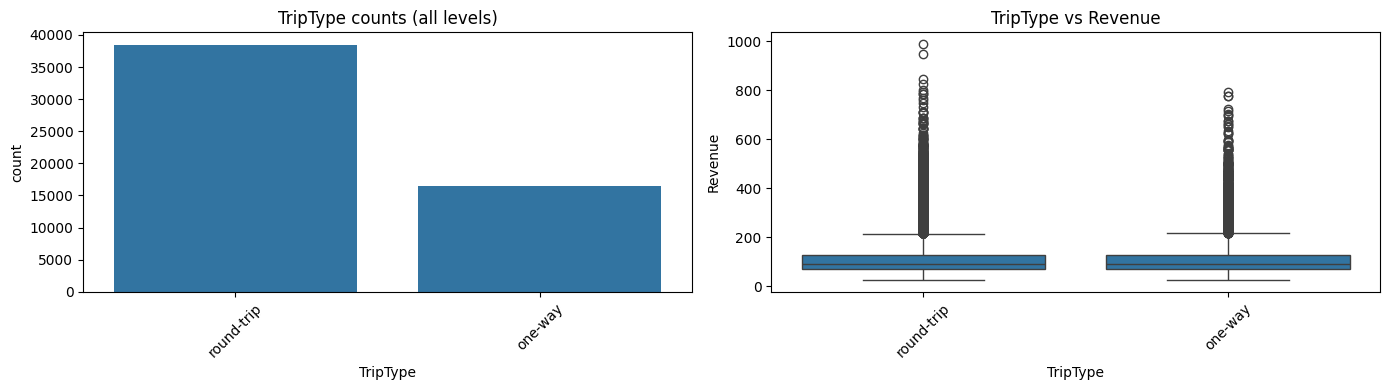

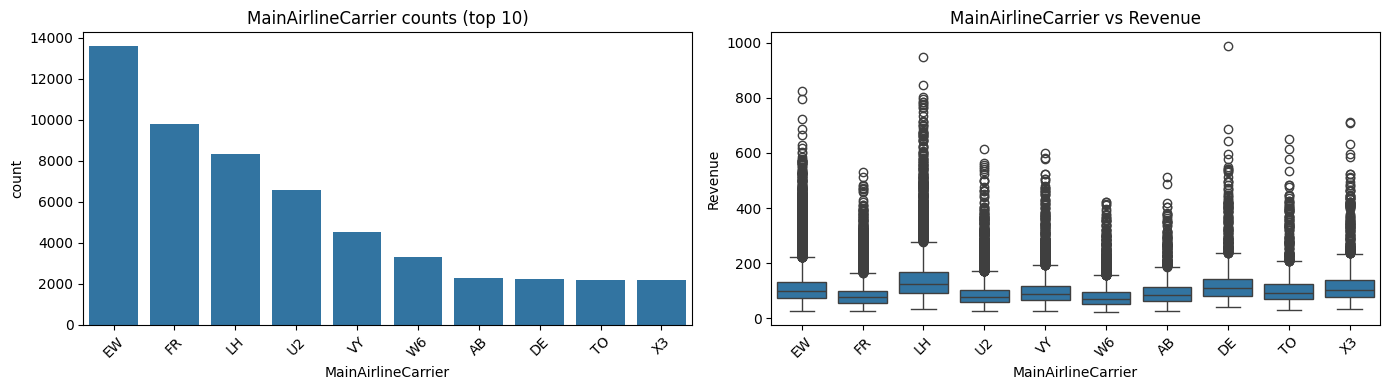

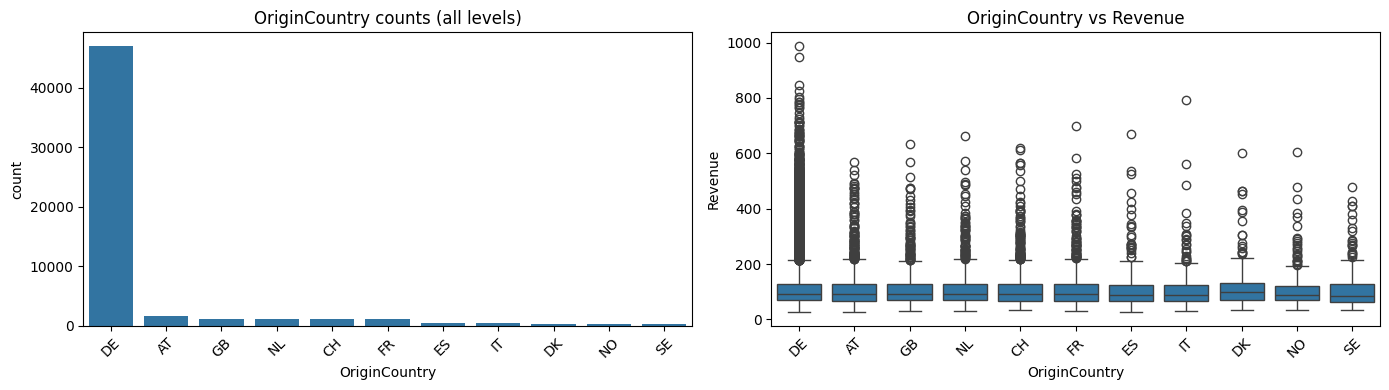

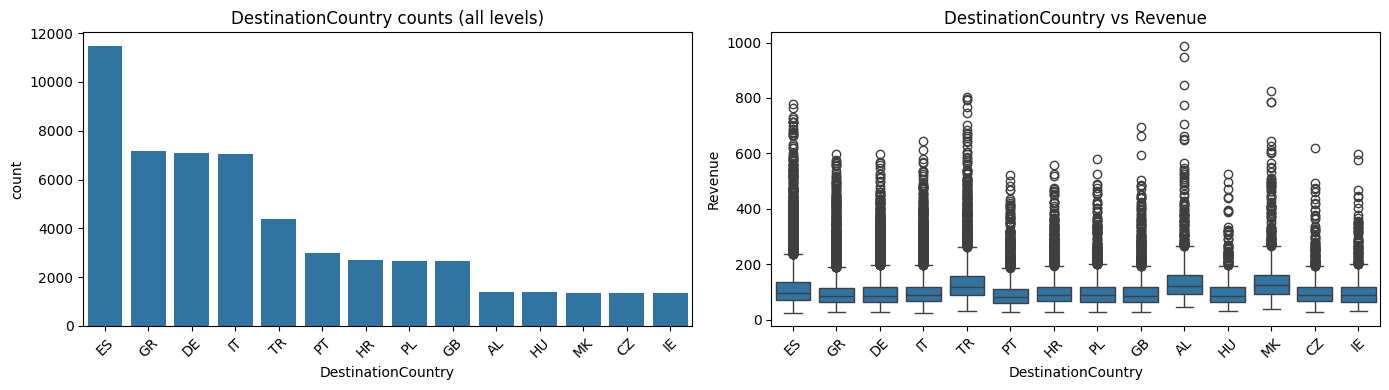

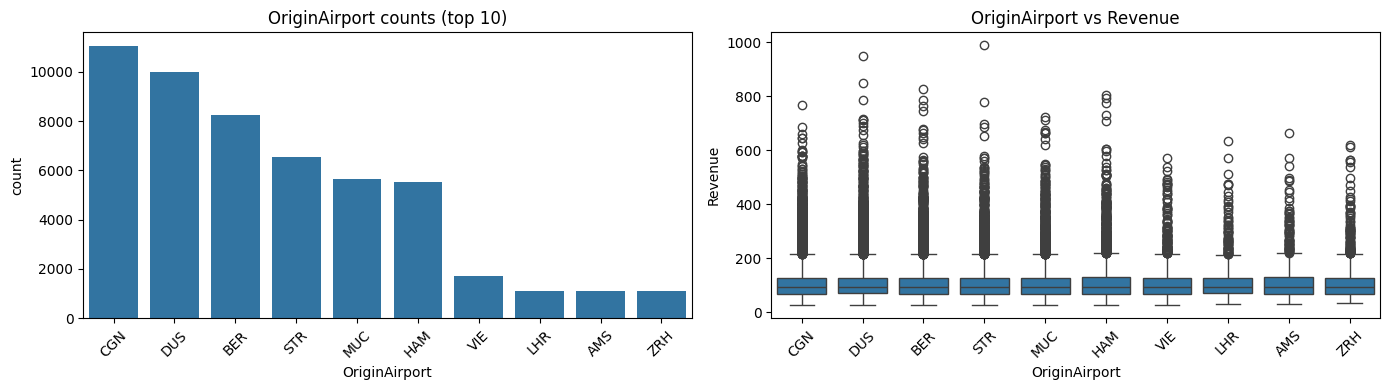

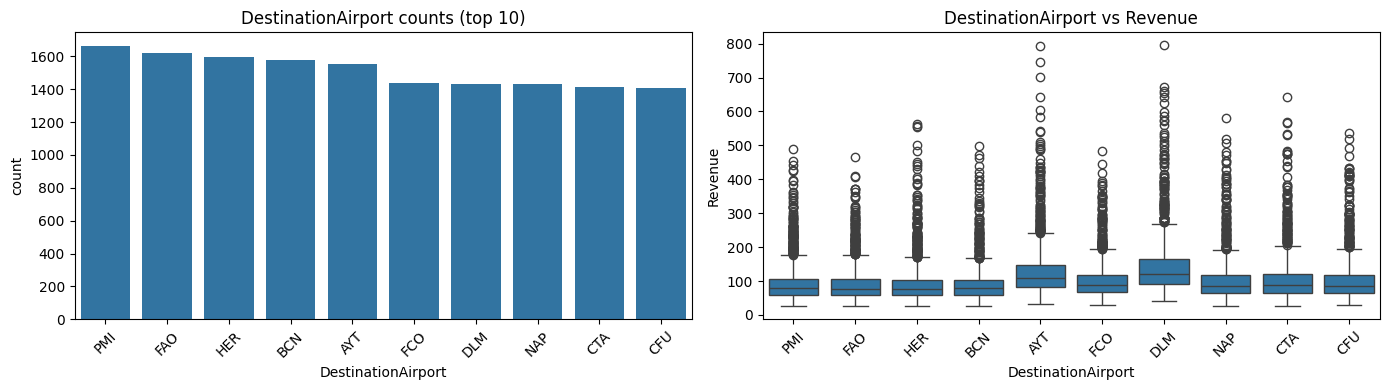

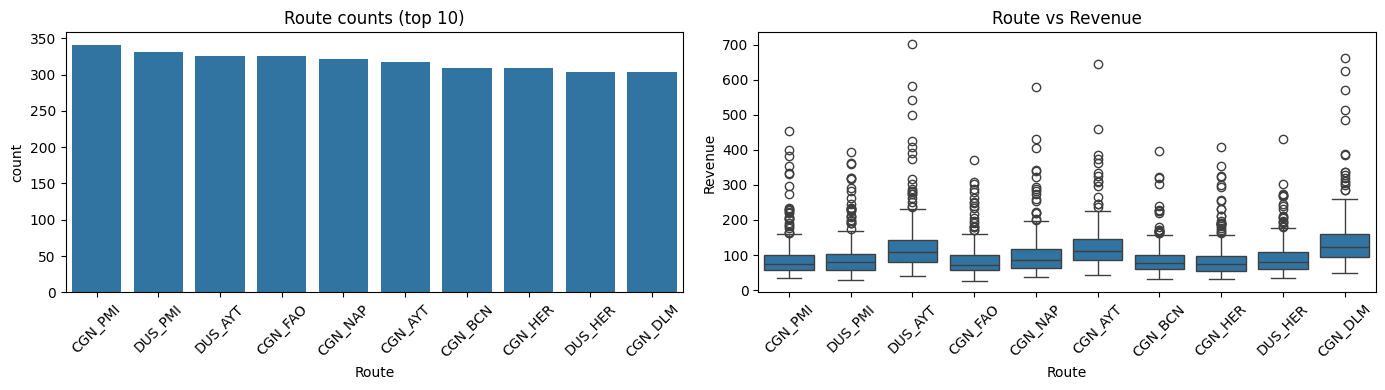

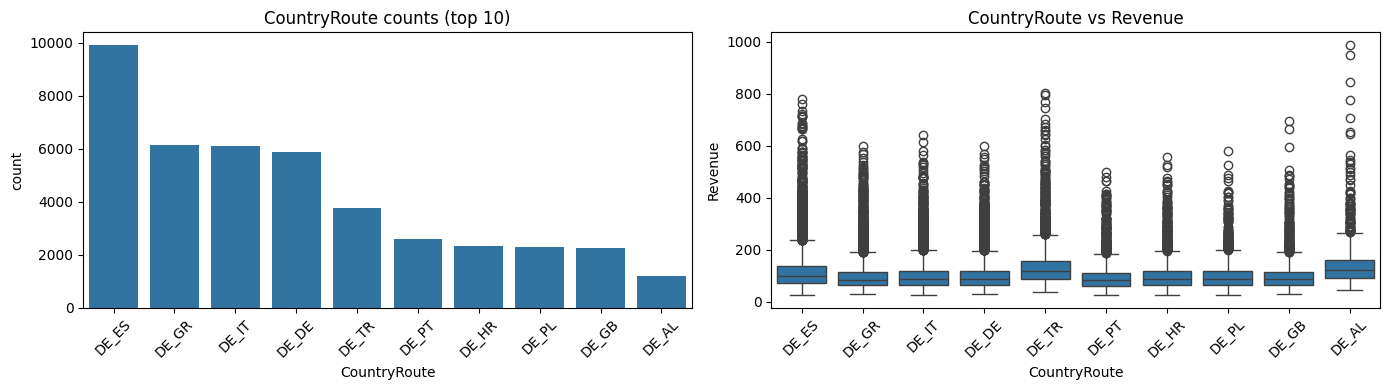

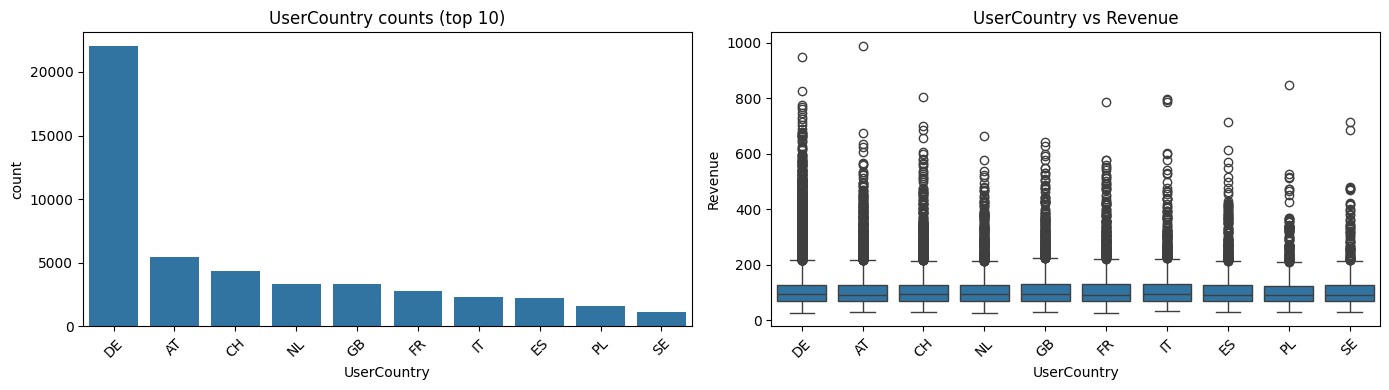

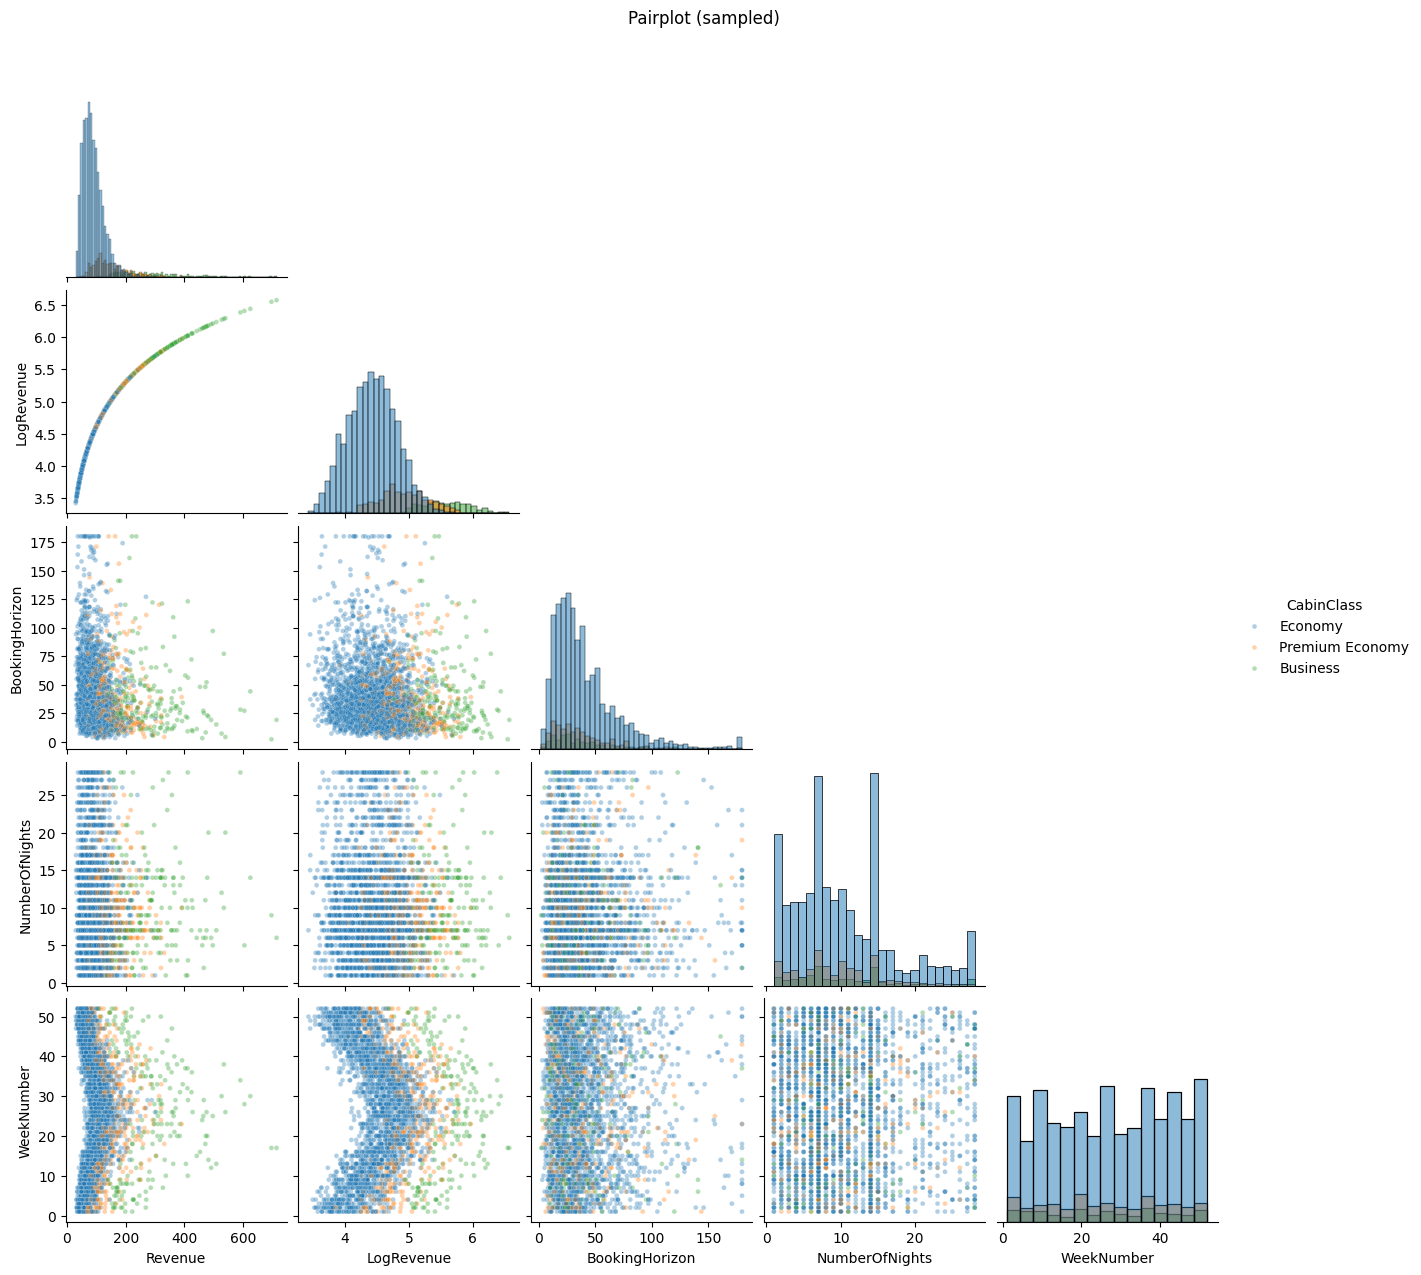

In [13]:
eda_df = df.copy()

TARGET_COL = "Revenue"
TOP_N = 10

EDA_NUMERIC_COLS = [
    "WeekNumber", "WeekSin", "WeekCos",
    "IsConnectingFlight", "NumberOfNights", "BookingHorizon",
    "NumberOfRedirects", "Revenue", "LogRevenue",
]

EDA_CATEGORICAL_COLS = [
    "CabinClass", "TripType", "MainAirlineCarrier",
    "OriginCountry", "DestinationCountry",
    "OriginAirport", "DestinationAirport",
    "Route", "CountryRoute", "UserCountry",
]

EDA_HIGH_CARD = [
    "Route", "CountryRoute", "OriginAirport",
    "DestinationAirport", "MainAirlineCarrier", "UserCountry",
]

print("EDA rows:", len(eda_df))
print("Weeks:", eda_df["WeekNumber"].min(), "to", eda_df["WeekNumber"].max())

# --------------------------------------------------
# 1) Numeric histograms
# --------------------------------------------------
eda_df[EDA_NUMERIC_COLS].hist(figsize=(14, 10), bins=30, edgecolor="black")
plt.suptitle("Numeric feature distributions (competitors)", y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2) Correlation heatmap
# --------------------------------------------------
plt.figure(figsize=(9, 7))
corr = eda_df[EDA_NUMERIC_COLS].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3) Revenue by week (good for slides)
# --------------------------------------------------
weekly = (
    eda_df.groupby("WeekNumber")[TARGET_COL]
    .agg(["mean", "median", "count"])
    .reset_index()
)

plt.figure(figsize=(12, 4))
plt.plot(weekly["WeekNumber"], weekly["mean"], marker="o", label="Mean Revenue")
plt.plot(weekly["WeekNumber"], weekly["median"], marker="o", label="Median Revenue")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.title("Competitor revenue by week")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3b) Revenue by week — all carriers
# --------------------------------------------------
weekly_by_carrier = (
    eda_df.groupby(["WeekNumber", "MainAirlineCarrier"], as_index=False)[TARGET_COL]
    .mean()
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=weekly_by_carrier,
    x="WeekNumber",
    y=TARGET_COL,
    hue="MainAirlineCarrier",
    marker="o",
    linewidth=1.5,
)
plt.xlabel("Week")
plt.ylabel("Mean Revenue")
plt.title("Mean revenue by week — all carriers")
plt.legend(title="Carrier", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 4) Raw vs log revenue
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(eda_df[TARGET_COL], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Revenue (raw)")

sns.histplot(eda_df["LogRevenue"], bins=40, kde=True, color="orange", ax=axes[1])
axes[1].set_title("LogRevenue")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 5) Categorical vs Revenue
# --------------------------------------------------
def plot_cat_vs_revenue(col, data, top_n=10):
    if col in EDA_HIGH_CARD:
        top_vals = data[col].value_counts().head(top_n).index
        tmp = data[data[col].isin(top_vals)]
        title_suffix = f"(top {top_n})"
    else:
        tmp = data
        top_vals = data[col].value_counts().index
        title_suffix = "(all levels)"

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.countplot(data=tmp, x=col, order=top_vals, ax=axes[0])
    axes[0].set_title(f"{col} counts {title_suffix}")
    axes[0].tick_params(axis="x", rotation=45)

    sns.boxplot(data=tmp, x=col, y=TARGET_COL, order=top_vals, ax=axes[1])
    axes[1].set_title(f"{col} vs {TARGET_COL}")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

for col in EDA_CATEGORICAL_COLS:
    plot_cat_vs_revenue(col, eda_df, top_n=TOP_N)

# --------------------------------------------------
# 6) Pairplot (small sample — avoid slow notebook)
# --------------------------------------------------
pair_cols = ["Revenue", "LogRevenue", "BookingHorizon", "NumberOfNights", "WeekNumber"]
sample_df = eda_df[pair_cols + ["CabinClass"]].dropna().sample(
    min(3000, len(eda_df)), random_state=42
)

sns.pairplot(
    sample_df,
    hue="CabinClass",
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.35, "s": 12},
)
plt.suptitle("Pairplot (sampled)", y=1.02)
plt.show()

## Insights     

1) Revenue is skewed — most fares are low (~€50–200); a few high values pull the mean up → we model LogRevenue.

2) Log transform works — LogRevenue looks roughly bell-shaped → better for training; we report MAE back in €.

3) Clear seasonality — revenue rises in spring, peaks around W25–W30, then falls → week features + Holt trend make sense.

4) Mean > median every week — a few expensive trips lift the average → typical fare is lower than the mean.

5) CabinClass drives price — Economy cheap, Business expensive → matches why it’s top in feature importance.

6) Trip length clusters at 7 & 14 nights — mostly one- / two-week leisure trips, not random spread.

7) Most bookings 15–50 days out — BookingHorizon is right-skewed; long advance bookings are rare.

8) Weak linear correlation ≠ useless — BookingHorizon/Nights look weak on the heatmap, but RF still uses them via splits; WeekCos + cabin/carrier matter most.

9) WeekSin & WeekCos — sin/cos encode yearly cycle so W52 is close to W1; a straight week number can’t do that. Matches the seasonal chart.

10) We can see different price of carriers price over weeks 

## Feature List

In [15]:
BASE_FEATURES = [
    "WeekNumber",
    "WeekSin",
    "WeekCos",
    "Route",
    "CountryRoute",
    "OriginAirport",
    "OriginCountry",
    "DestinationAirport",
    "DestinationCountry",
    "MainAirlineCarrier",
    "IsConnectingFlight",
    "UserCountry",
    "TripType",
    "CabinClass",
    "NumberOfNights",
    "BookingHorizon",
]

CATEGORICAL_FEATURES = [
    "Route",
    "CountryRoute",
    "OriginAirport",
    "OriginCountry",
    "DestinationAirport",
    "DestinationCountry",
    "MainAirlineCarrier",
    "UserCountry",
    "TripType",
    "CabinClass",
]

NUMERIC_FEATURES = [
    "WeekNumber",
    "WeekSin",
    "WeekCos",
    "IsConnectingFlight",
    "NumberOfNights",
    "BookingHorizon",
]

RESIDUAL_FEATURES = [
    col for col in BASE_FEATURES
    if col not in ["WeekNumber", "WeekSin", "WeekCos"]
]

RESIDUAL_CATEGORICAL_FEATURES = [
    col for col in CATEGORICAL_FEATURES
    if col in RESIDUAL_FEATURES
]

RESIDUAL_NUMERIC_FEATURES = [
    col for col in NUMERIC_FEATURES
    if col in RESIDUAL_FEATURES
]


# =========================
# 6. Leakage safety checks
# =========================

BAD_FEATURES = {
    "Revenue",
    "LogRevenue",
    "ResidualLogRevenue",
    "TrendLogPrediction",
    "RedirectsCount",
    "NumberOfRedirects",
    "Bookings",
    "BookingCount",
}

assert not any(col in BAD_FEATURES for col in BASE_FEATURES), \
    "Leakage risk: bad target/future column found in BASE_FEATURES."

assert not any(col in BAD_FEATURES for col in RESIDUAL_FEATURES), \
    "Leakage risk: bad target/future column found in RESIDUAL_FEATURES."

missing_features = [col for col in BASE_FEATURES if col not in df.columns]

assert len(missing_features) == 0, \
    f"Missing required features: {missing_features}"

print("\nLeakage feature check passed.")
print("All required model features exist.")




Leakage feature check passed.
All required model features exist.


# Time Split ( Train Test )

In [16]:
train_df = df[df["WeekNumber"].between(1, 41)].copy()
test_df = df[df["WeekNumber"].between(42, 52)].copy()

train_weeks = sorted(train_df["WeekNumber"].unique())
test_weeks = sorted(test_df["WeekNumber"].unique())

assert len(train_df) > 0, "Train data is empty."
assert len(test_df) > 0, "Test data is empty."

assert set(train_weeks).isdisjoint(set(test_weeks)), \
    "Leakage: train and test weeks overlap!"

assert max(train_weeks) < min(test_weeks), \
    "Leakage: train weeks must be before test weeks!"

print("\n" + "=" * 80)
print("TIME SPLIT")
print("=" * 80)
print(f"Train weeks : W{min(train_weeks):02d} to W{max(train_weeks):02d}")
print(f"Test weeks  : W{min(test_weeks):02d} to W{max(test_weeks):02d}")
print(f"Train rows  : {len(train_df)}")
print(f"Test rows   : {len(test_df)}")


TIME SPLIT
Train weeks : W01 to W41
Test weeks  : W42 to W52
Train rows  : 32638
Test rows   : 8778


# Helper Function

In [17]:
def safe_expm1(x):
    """
    Safely convert log1p prediction back to revenue scale.
    """
    x = np.asarray(x)
    x = np.clip(x, -50, 20)
    return np.maximum(0, np.expm1(x))


def evaluate_model(name, y_true, y_pred):
    """
    Print and return MAE, RMSE, R2.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("-" * 60)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }


def make_one_hot_encoder():
    """
    Compatible with older and newer sklearn versions.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_rf_pipeline(categorical_features, numeric_features, min_samples_leaf=5):
    """
    Build Random Forest pipeline with preprocessing.
    """
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, categorical_features),
            ("num", numeric_transformer, numeric_features),
        ],
        remainder="drop",
    )

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=5,
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    return pipeline


def dedupe_columns(cols):
    """
    Remove duplicate column names while preserving order.
    """
    return list(dict.fromkeys(cols))


# Model 1: Current Log RF

In [18]:
FIXED_WEIGHT_LOG_RF = 0.313
FIXED_WEIGHT_HOLT_RESIDUAL = 0.687

assert abs((FIXED_WEIGHT_LOG_RF + FIXED_WEIGHT_HOLT_RESIDUAL) - 1.0) < 1e-9

In [19]:
def fit_predict_current_log_rf(train_part_df, pred_part_df):
    """
    Train standard log Revenue RF.
    """
    model = build_rf_pipeline(
        CATEGORICAL_FEATURES,
        NUMERIC_FEATURES,
        min_samples_leaf=5,
    )

    model.fit(
        train_part_df[BASE_FEATURES],
        train_part_df["LogRevenue"],
    )

    pred_log = model.predict(pred_part_df[BASE_FEATURES])
    pred_revenue = safe_expm1(pred_log)

    return pred_log, pred_revenue, model



# Model 2: Holt + RF Residual

In [20]:


def fit_holt_trend(train_part_df, train_part_weeks, pred_weeks):
    """
    Fit Holt damped trend only on training weeks.
    Forecast prediction weeks.
    """
    weekly_train_log = (
        train_part_df
        .groupby("WeekNumber")["LogRevenue"]
        .mean()
        .reindex(train_part_weeks)
        .interpolate()
        .ffill()
        .bfill()
    )

    holt_model = ExponentialSmoothing(
        weekly_train_log.values,
        trend="add",
        damped_trend=True,
        seasonal=None,
        initialization_method="estimated",
    ).fit(optimized=True)

    trend_train_log = pd.Series(
        holt_model.fittedvalues,
        index=train_part_weeks,
    )

    trend_pred_log = pd.Series(
        holt_model.forecast(len(pred_weeks)),
        index=pred_weeks,
    )

    return trend_train_log, trend_pred_log, holt_model


def fit_predict_holt_residual_rf_with_parts(
    train_part_df,
    pred_part_df,
    train_part_weeks,
    pred_weeks,
):
    """
    Train Holt trend + RF residual.

    Final log prediction:
        HoltTrendLog + RFResidualLog
    """
    train_part_df = train_part_df.copy()
    pred_part_df = pred_part_df.copy()

    trend_train_log, trend_pred_log, holt_model = fit_holt_trend(
        train_part_df=train_part_df,
        train_part_weeks=train_part_weeks,
        pred_weeks=pred_weeks,
    )

    train_part_df["TrendLogPrediction"] = train_part_df["WeekNumber"].map(
        trend_train_log
    )

    pred_part_df["TrendLogPrediction"] = pred_part_df["WeekNumber"].map(
        trend_pred_log
    )

    train_part_df["ResidualLogRevenue"] = (
        train_part_df["LogRevenue"]
        - train_part_df["TrendLogPrediction"]
    )

    residual_model = build_rf_pipeline(
        RESIDUAL_CATEGORICAL_FEATURES,
        RESIDUAL_NUMERIC_FEATURES,
        min_samples_leaf=5,
    )

    residual_model.fit(
        train_part_df[RESIDUAL_FEATURES],
        train_part_df["ResidualLogRevenue"],
    )

    residual_pred_log = residual_model.predict(
        pred_part_df[RESIDUAL_FEATURES]
    )

    trend_pred_log_by_row = pred_part_df["TrendLogPrediction"].values

    final_log_pred = trend_pred_log_by_row + residual_pred_log
    final_revenue_pred = safe_expm1(final_log_pred)

    return {
        "final_log_pred": final_log_pred,
        "final_revenue_pred": final_revenue_pred,
        "trend_log_pred": trend_pred_log_by_row,
        "residual_log_pred": residual_pred_log,
        "holt_model": holt_model,
        "residual_model": residual_model,
    }


# Final fixed weighted ensemble

In [21]:
def fit_predict_final_point_model(
    train_part_df,
    pred_part_df,
    train_part_weeks,
    pred_weeks,
):
    """
    Fits both point models and creates final fixed weighted ensemble.
    """
    current_log_pred, current_revenue_pred, current_model = fit_predict_current_log_rf(
        train_part_df=train_part_df,
        pred_part_df=pred_part_df,
    )

    holt_parts = fit_predict_holt_residual_rf_with_parts(
        train_part_df=train_part_df,
        pred_part_df=pred_part_df,
        train_part_weeks=train_part_weeks,
        pred_weeks=pred_weeks,
    )

    holt_log_pred = holt_parts["final_log_pred"]
    holt_revenue_pred = holt_parts["final_revenue_pred"]

    weighted_revenue_pred = (
        FIXED_WEIGHT_LOG_RF * current_revenue_pred
        + FIXED_WEIGHT_HOLT_RESIDUAL * holt_revenue_pred
    )

    weighted_log_pred = np.log1p(weighted_revenue_pred)

    output_base_cols = [
        "FlightWeek",
        "WeekNumber",
        "Revenue",
        "LogRevenue",
    ] + BASE_FEATURES

    output_base_cols = dedupe_columns(output_base_cols)

    out = pred_part_df[output_base_cols].copy()

    # Extra safety against duplicate columns
    out = out.loc[:, ~out.columns.duplicated()].copy()

    out["Pred_CurrentLogRF"] = current_revenue_pred
    out["Pred_HoltResidualRF"] = holt_revenue_pred
    out["Pred_WeightedEnsemble"] = weighted_revenue_pred

    out["LogPred_CurrentLogRF"] = current_log_pred
    out["LogPred_HoltResidualRF"] = holt_log_pred
    out["LogPred_WeightedEnsemble"] = weighted_log_pred

    out["HoltTrendLogPred"] = holt_parts["trend_log_pred"]
    out["HoltResidualLogPred"] = holt_parts["residual_log_pred"]

    out["ActualHoltResidualLog"] = (
        out["LogRevenue"]
        - out["HoltTrendLogPred"]
    )

    out["PointError"] = (
        out["Revenue"]
        - out["Pred_WeightedEnsemble"]
    )

    out["AbsPointError"] = np.abs(out["PointError"])

    return out, current_model, holt_parts


# Train final model and evaluate

In [22]:
print("\n" + "=" * 80)
print("FINAL POINT MODEL ON FULL TRAIN")
print("=" * 80)

test_point_df, final_log_rf_model, final_holt_parts = fit_predict_final_point_model(
    train_part_df=train_df,
    pred_part_df=test_df,
    train_part_weeks=train_weeks,
    pred_weeks=test_weeks,
)



FINAL POINT MODEL ON FULL TRAIN


# Final point model metrics

In [23]:
point_metrics = []

point_metrics.append(
    evaluate_model(
        "Test: Current Log RF",
        test_point_df["Revenue"],
        test_point_df["Pred_CurrentLogRF"],
    )
)

point_metrics.append(
    evaluate_model(
        "Test: Holt + Residual RF",
        test_point_df["Revenue"],
        test_point_df["Pred_HoltResidualRF"],
    )
)

point_metrics.append(
    evaluate_model(
        "Test: Fixed Weighted Ensemble",
        test_point_df["Revenue"],
        test_point_df["Pred_WeightedEnsemble"],
    )
)

point_metrics_df = pd.DataFrame(point_metrics)

print("\n" + "=" * 80)
print("POINT MODEL FINAL TEST COMPARISON")
print("=" * 80)
print(point_metrics_df.sort_values("MAE").to_string(index=False))



Test: Current Log RF
------------------------------------------------------------
MAE  : 15.8115
RMSE : 21.9446
R2   : 0.7746

Test: Holt + Residual RF
------------------------------------------------------------
MAE  : 11.0282
RMSE : 16.8334
R2   : 0.8674

Test: Fixed Weighted Ensemble
------------------------------------------------------------
MAE  : 10.6057
RMSE : 16.1395
R2   : 0.8781

POINT MODEL FINAL TEST COMPARISON
                        Model       MAE      RMSE       R2
Test: Fixed Weighted Ensemble 10.605744 16.139453 0.878084
     Test: Holt + Residual RF 11.028248 16.833375 0.867375
         Test: Current Log RF 15.811514 21.944625 0.774607


# Residual component metrics

In [24]:
residual_component_metrics = []

residual_component_metrics.append(
    evaluate_model(
        "Test: RF Residual Component - Log Scale",
        test_point_df["ActualHoltResidualLog"],
        test_point_df["HoltResidualLogPred"],
    )
)

residual_component_metrics_df = pd.DataFrame(residual_component_metrics)




Test: RF Residual Component - Log Scale
------------------------------------------------------------
MAE  : 0.1364
RMSE : 0.1713
R2   : 0.8403


# Weekly and Plotting


WEEKLY TEST COMPARISON
FlightWeek  WeekNumber  ActualRevenue  CurrentLogRF  HoltResidualRF  WeightedEnsemble  MAE_Weighted  WeightedError
  2024-W42          42      92.764126     93.247038       90.857310         91.605295     12.173937       1.158831
  2024-W43          43      90.098839     93.454278       87.940457         89.666283     11.977609       0.432556
  2024-W44          44      85.451519     89.134482       83.469061         85.242338     11.327328       0.209181
  2024-W45          45      86.667285     91.699328       83.506947         86.071162     11.912567       0.596123
  2024-W46          46      83.710324     90.644880       80.125398         83.417996     11.366985       0.292329
  2024-W47          47      76.553974     87.804887       74.489211         78.657017     10.171688      -2.103043
  2024-W48          48      74.575883     87.207856       70.633089         75.820991     10.109424      -1.245108
  2024-W49          49      72.962732     88.422083     

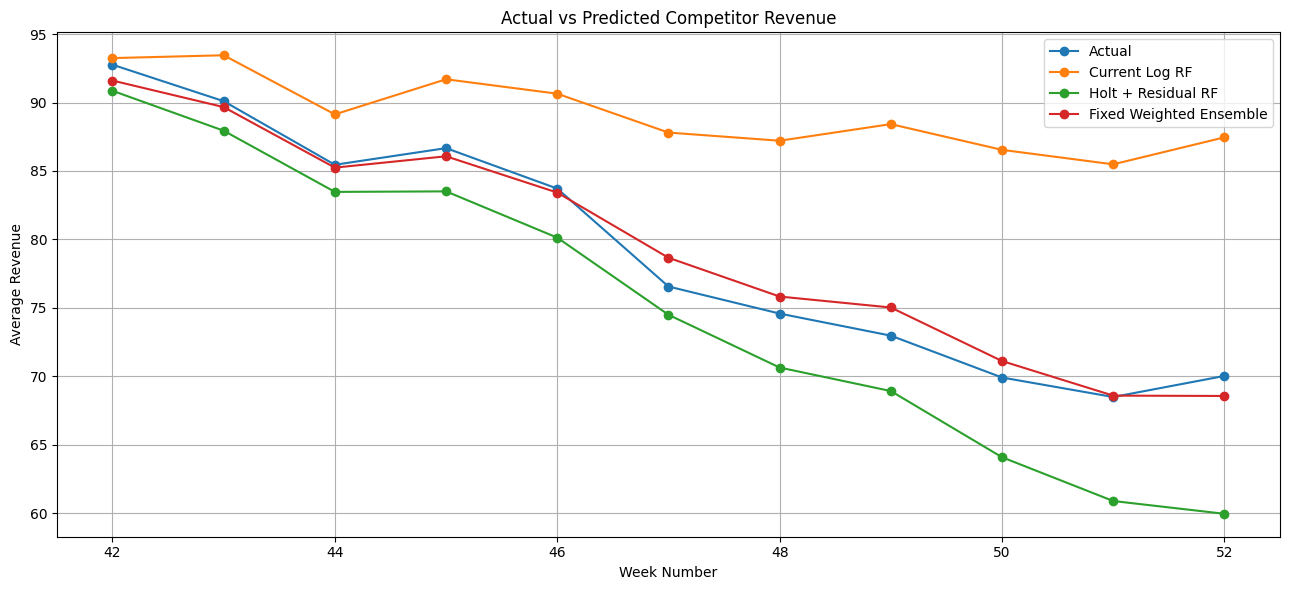

In [25]:
weekly_comparison = (
    test_point_df
    .groupby(["FlightWeek", "WeekNumber"], as_index=False)
    .agg(
        ActualRevenue=("Revenue", "mean"),
        CurrentLogRF=("Pred_CurrentLogRF", "mean"),
        HoltResidualRF=("Pred_HoltResidualRF", "mean"),
        WeightedEnsemble=("Pred_WeightedEnsemble", "mean"),
        MAE_Weighted=("AbsPointError", "mean"),
    )
    .sort_values("WeekNumber")
)

weekly_comparison["WeightedError"] = (
    weekly_comparison["ActualRevenue"]
    - weekly_comparison["WeightedEnsemble"]
)

print("\n" + "=" * 80)
print("WEEKLY TEST COMPARISON")
print("=" * 80)
print(weekly_comparison.to_string(index=False))


# =========================
# 15. Plot weekly actual vs predicted
# =========================

plt.figure(figsize=(13, 6))

plt.plot(
    weekly_comparison["WeekNumber"],
    weekly_comparison["ActualRevenue"],
    marker="o",
    label="Actual",
)

plt.plot(
    weekly_comparison["WeekNumber"],
    weekly_comparison["CurrentLogRF"],
    marker="o",
    label="Current Log RF",
)

plt.plot(
    weekly_comparison["WeekNumber"],
    weekly_comparison["HoltResidualRF"],
    marker="o",
    label="Holt + Residual RF",
)

plt.plot(
    weekly_comparison["WeekNumber"],
    weekly_comparison["WeightedEnsemble"],
    marker="o",
    label="Fixed Weighted Ensemble",
)

plt.xlabel("Week Number")
plt.ylabel("Average Revenue")
plt.title("Actual vs Predicted Competitor Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Final summary print

In [26]:
best_row = point_metrics_df.sort_values("MAE").iloc[0]

print("\n" + "=" * 80)
print("FINAL SELECTED MODEL")
print("=" * 80)
print("Model : Fixed Weighted Ensemble")
print(f"Weight Current Log RF      : {FIXED_WEIGHT_LOG_RF:.3f}")
print(f"Weight Holt + Residual RF  : {FIXED_WEIGHT_HOLT_RESIDUAL:.3f}")
print(f"MAE   : {best_row['MAE']:.4f}")
print(f"RMSE  : {best_row['RMSE']:.4f}")
print(f"R2    : {best_row['R2']:.4f}")


FINAL SELECTED MODEL
Model : Fixed Weighted Ensemble
Weight Current Log RF      : 0.313
Weight Holt + Residual RF  : 0.687
MAE   : 10.6057
RMSE  : 16.1395
R2    : 0.8781


1) Task: Predict competitor Revenue (EW removed); train W01–37, test W38–W52; model LogRevenue, report MAE in €.

2) Three models: Log RF (features + seasonality), Holt + Residual RF (weekly trend + RF on residual), Fixed Ensemble = 31.3% Log RF + 68.7% Holt+Residual.

3) Test winner: Ensemble — MAE 10.7, R² 0.88 (beats Log RF 15.1 / 0.80 and Holt+Residual 11.5 / 0.86).

4) Chart: In test weeks revenue drops; Log RF too high, Holt+Residual too low at the end; ensemble tracks actual best.

5) Final model: Fixed Weighted Ensemble for Case Study 1 competitor price forecasting.

6) Conclusion: The Fixed Weighted Ensemble (31.3% Log RF + 68.7% Holt+Residual RF) is our final competitor revenue model, achieving MAE ~€10.7 and R² ~0.88 on the hold-out test weeks (W38–W52). It works because Log RF captures route, cabin, and carrier effects well but stays too high when revenue drops, while Holt+Residual tracks the weekly trend but underpredicts at the end — the ensemble combines both strengths. This aligns with our EDA: strong seasonality, skewed fares, and a late-year decline in the test period. The model is explainable, time-split cleanly with no EW leakage, and suitable as a competitor price benchmark for pricing decisions. Main limitations are fixed ensemble weights (should be stated as train-derived), aggregated Skyscanner data rather than live feeds, and row-level predictions that still need care when summed to weekly totals. Overall, Case Study 1 is in good shape for submission; EW redirect prediction remains a separate bonus.

MODEL 1: CURRENT LOG RF - TOP TRANSFORMED FEATURES
                        Feature  Importance
        cat__CabinClass_Economy    0.329062
                   num__WeekCos    0.222926
     cat__MainAirlineCarrier_LH    0.116845
       cat__CabinClass_Business    0.058121
            num__BookingHorizon    0.038596
                num__WeekNumber    0.028418
cat__CabinClass_Premium Economy    0.023900
     cat__DestinationCountry_TR    0.020626
     cat__MainAirlineCarrier_DE    0.017763
        num__IsConnectingFlight    0.015043
     cat__MainAirlineCarrier_X3    0.013700
            num__NumberOfNights    0.010857
    cat__DestinationAirport_ACE    0.009461
    cat__DestinationAirport_TFS    0.008819
    cat__DestinationAirport_LPA    0.008050
    cat__DestinationAirport_FUE    0.007756
     cat__MainAirlineCarrier_VY    0.005667
     cat__MainAirlineCarrier_TO    0.005513
     cat__DestinationCountry_MK    0.004855
                   num__WeekSin    0.004661
    cat__DestinationAirpo

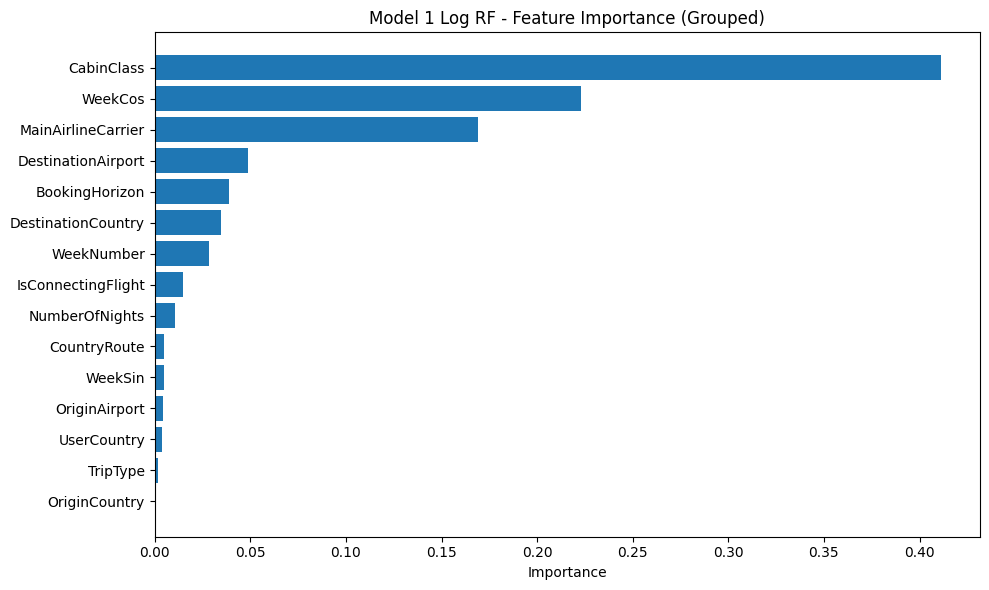


MODEL 2: RESIDUAL RF - TOP TRANSFORMED FEATURES
                        Feature  Importance
        cat__CabinClass_Economy    0.431245
     cat__MainAirlineCarrier_LH    0.152283
cat__CabinClass_Premium Economy    0.063435
            num__BookingHorizon    0.047919
       cat__CabinClass_Business    0.046907
     cat__DestinationCountry_TR    0.028332
     cat__MainAirlineCarrier_DE    0.023650
        num__IsConnectingFlight    0.022674
     cat__MainAirlineCarrier_X3    0.018787
    cat__DestinationAirport_ACE    0.014560
            num__NumberOfNights    0.014365
    cat__DestinationAirport_LPA    0.014103
    cat__DestinationAirport_TFS    0.013957
    cat__DestinationAirport_FUE    0.013814
     cat__MainAirlineCarrier_VY    0.009087
     cat__MainAirlineCarrier_TO    0.008985
    cat__DestinationAirport_SKP    0.007903
    cat__DestinationAirport_TIA    0.007727
     cat__DestinationCountry_MK    0.006868
     cat__DestinationCountry_AL    0.006757
     cat__MainAirlineCarrie

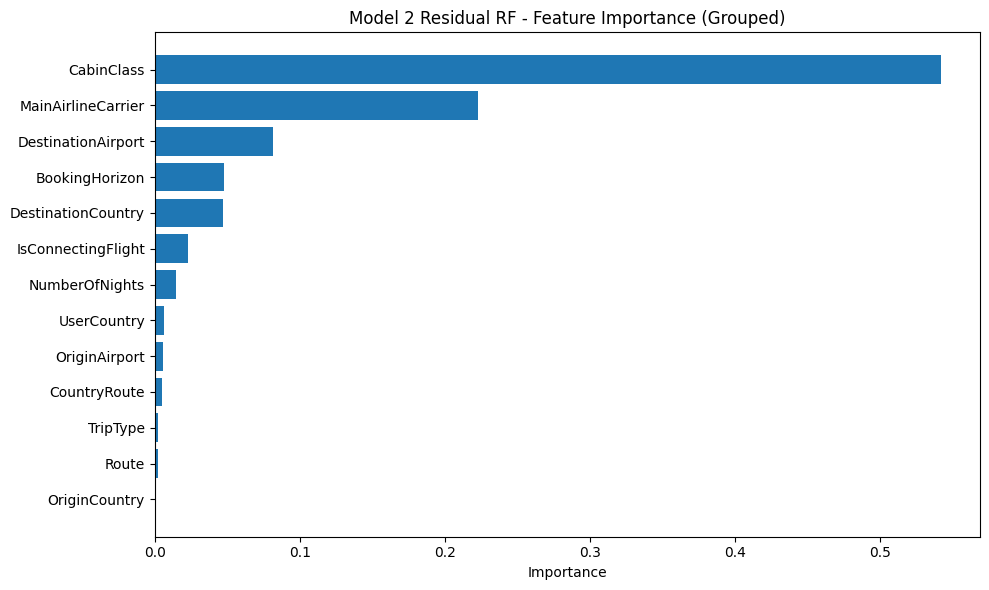

In [27]:

def get_rf_feature_importance(pipeline, top_n=30):
    """
    Extract RF feature importances from a fitted sklearn Pipeline
    with ColumnTransformer + OneHotEncoder preprocessing.
    """
    preprocessor = pipeline.named_steps["preprocessor"]
    rf_model = pipeline.named_steps["model"]

    feature_names = preprocessor.get_feature_names_out()
    importances = rf_model.feature_importances_

    importance_df = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances,
        })
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    print(importance_df.head(top_n).to_string(index=False))
    return importance_df


def aggregate_importance_by_raw_feature(importance_df):
    """
    Group one-hot columns back to original feature names.
    Example: cat__Route_CGN_LHR -> Route
    """
    def to_raw_name(name):
        # handle nested pipeline names from ColumnTransformer
        if name.startswith("cat__"):
            # cat__onehot__Route_CGN_LHR  OR  cat__Route_CGN_LHR
            parts = name.split("__")
            if len(parts) >= 3:
                return parts[2].split("_", 1)[0]
            if len(parts) == 2:
                return parts[1].split("_", 1)[0]

        if name.startswith("num__"):
            return name.replace("num__", "")

        return name

    grouped = (
        importance_df
        .assign(RawFeature=importance_df["Feature"].map(to_raw_name))
        .groupby("RawFeature", as_index=False)["Importance"]
        .sum()
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    return grouped


def plot_top_features(importance_df, feature_col, title, top_n=15):
    top = importance_df.head(top_n).iloc[::-1]

    plt.figure(figsize=(10, 6))
    plt.barh(top[feature_col], top["Importance"])
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


# ============================================================
# 1) MODEL 1: CURRENT LOG RF
# ============================================================

print("=" * 80)
print("MODEL 1: CURRENT LOG RF - TOP TRANSFORMED FEATURES")
print("=" * 80)

log_rf_importance = get_rf_feature_importance(final_log_rf_model, top_n=30)

log_rf_grouped = aggregate_importance_by_raw_feature(log_rf_importance)

print("\nMODEL 1: GROUPED BY ORIGINAL FEATURE")
print("-" * 80)
print(log_rf_grouped.head(20).to_string(index=False))

plot_top_features(
    log_rf_grouped,
    feature_col="RawFeature",
    title="Model 1 Log RF - Feature Importance (Grouped)",
    top_n=15,
)


# ============================================================
# 2) MODEL 2: RESIDUAL RF (inside Holt + Residual)
# ============================================================

print("\n" + "=" * 80)
print("MODEL 2: RESIDUAL RF - TOP TRANSFORMED FEATURES")
print("=" * 80)

residual_model = final_holt_parts["residual_model"]

residual_importance = get_rf_feature_importance(residual_model, top_n=30)

residual_grouped = aggregate_importance_by_raw_feature(residual_importance)

print("\nMODEL 2: GROUPED BY ORIGINAL FEATURE")
print("-" * 80)
print(residual_grouped.head(20).to_string(index=False))

plot_top_features(
    residual_grouped,
    feature_col="RawFeature",
    title="Model 2 Residual RF - Feature Importance (Grouped)",
    top_n=15,
)


# EW NUMBER OF REDIRECT ( BONUS )

In [28]:
print("\n" + "=" * 80)
print("BONUS SETUP 1: EW REDIRECT DATA")
print("=" * 80)

redirect_df = pd.read_csv("skyscanner_airfare_data.csv")

REDIRECT_TARGET_CANDIDATES = ["NumberOfRedirects", "RedirectsCount"]
REDIRECT_TARGET = next(
    (c for c in REDIRECT_TARGET_CANDIDATES if c in redirect_df.columns), None
)
assert REDIRECT_TARGET is not None, f"Need one of {REDIRECT_TARGET_CANDIDATES}"
print("REDIRECT_TARGET =", REDIRECT_TARGET)

redirect_df = redirect_df.copy()
redirect_df[REDIRECT_TARGET] = pd.to_numeric(redirect_df[REDIRECT_TARGET], errors="coerce")
redirect_df = redirect_df.dropna(
    subset=[REDIRECT_TARGET, "FlightWeek", "MainAirlineCarrier"]
).copy()

redirect_df = redirect_df[
    redirect_df["MainAirlineCarrier"].astype(str).str.upper() == "EW"
].copy()

redirect_df["WeekNumber"] = (
    redirect_df["FlightWeek"].astype(str).str.extract(r"W(\d+)").astype(int)
)
redirect_df["Route"] = (
    redirect_df["OriginAirport"].astype(str) + "_" + redirect_df["DestinationAirport"].astype(str)
)
redirect_df["CountryRoute"] = (
    redirect_df["OriginCountry"].astype(str) + "_" + redirect_df["DestinationCountry"].astype(str)
)
redirect_df["WeekSin"] = np.sin(2 * np.pi * redirect_df["WeekNumber"] / 52)
redirect_df["WeekCos"] = np.cos(2 * np.pi * redirect_df["WeekNumber"] / 52)

redirect_df[REDIRECT_TARGET] = np.maximum(0, redirect_df[REDIRECT_TARGET])
redirect_df["LogRedirects"] = np.log1p(redirect_df[REDIRECT_TARGET])

for col in ["IsConnectingFlight", "NumberOfNights", "BookingHorizon"]:
    if col in redirect_df.columns:
        if col == "IsConnectingFlight":
            s = redirect_df[col]
            if s.dtype == bool:
                redirect_df[col] = s.astype(int)
            else:
                m = {"true": 1, "false": 0, "yes": 1, "no": 0, "1": 1, "0": 0}
                redirect_df[col] = (
                    s.astype(str).str.lower().map(m)
                    .fillna(pd.to_numeric(s, errors="coerce"))
                    .fillna(0).astype(int)
                )
        else:
            redirect_df[col] = pd.to_numeric(redirect_df[col], errors="coerce")

# match main model split — change to 37 if your main section uses W01-37
REDIRECT_TRAIN_END_WEEK = 41

redirect_train_df = redirect_df[
    redirect_df["WeekNumber"].between(1, REDIRECT_TRAIN_END_WEEK)
].copy()
redirect_test_df = redirect_df[
    redirect_df["WeekNumber"].between(REDIRECT_TRAIN_END_WEEK + 1, 52)
].copy()

redirect_train_weeks = sorted(redirect_train_df["WeekNumber"].unique())
redirect_test_weeks = sorted(redirect_test_df["WeekNumber"].unique())

print("Train rows:", len(redirect_train_df), "| Test rows:", len(redirect_test_df))
print("Train weeks:", redirect_train_weeks[0], "-", redirect_train_weeks[-1])
print("Test weeks :", redirect_test_weeks[0], "-", redirect_test_weeks[-1])


BONUS SETUP 1: EW REDIRECT DATA
REDIRECT_TARGET = NumberOfRedirects
Train rows: 10734 | Test rows: 2850
Train weeks: 1 - 41
Test weeks : 42 - 52


# fEATURE Engineering 

In [29]:
print("\n" + "=" * 80)
print("BONUS SETUP 2: COMPETITOR FEATURES + FEATURE LISTS")
print("=" * 80)

assert "test_point_df" in globals(), "Run main ensemble cell first."
assert "Pred_WeightedEnsemble" in test_point_df.columns


def avg_lowest_50pct_model4(values):
    values = pd.Series(values).dropna().sort_values()
    if len(values) == 0:
        return np.nan
    return values.iloc[: max(1, int(np.ceil(len(values) * 0.50)))].mean()


MODEL4_COMPETITOR_NUMERIC_FEATURES = [
    "CompetitorOfferCount",
    "CompetitorAirlineCount",
    "CheapestCompetitorRevenue",
    "AvgCompetitorRevenue",
    "AvgLowest50PctCompetitorRevenue",
]


def build_competitor_feature_table(source_df, keys, price_col):
    return (
        source_df.groupby(keys)
        .agg(
            CompetitorOfferCount=("MainAirlineCarrier", "size"),
            CompetitorAirlineCount=("MainAirlineCarrier", "nunique"),
            CheapestCompetitorRevenue=(price_col, "min"),
            AvgCompetitorRevenue=(price_col, "mean"),
            AvgLowest50PctCompetitorRevenue=(price_col, avg_lowest_50pct_model4),
        )
        .reset_index()
    )


def merge_competitor_features_with_fallback(ew_df, feature_levels):
    out = ew_df.copy().reset_index(drop=True)
    out["_row_id"] = np.arange(len(out))
    for col in MODEL4_COMPETITOR_NUMERIC_FEATURES:
        out[col] = np.nan
    out["CompetitorMatchLevel"] = "none"

    for level_name, keys, feature_df in feature_levels:
        tmp = (
            out[["_row_id"] + keys]
            .merge(feature_df, on=keys, how="left")
            .sort_values("_row_id")
            .set_index("_row_id")
            .reindex(out["_row_id"])
        )
        needs_fill = out["CompetitorOfferCount"].isna()
        fill_mask = needs_fill & tmp["CompetitorOfferCount"].notna().values
        for col in MODEL4_COMPETITOR_NUMERIC_FEATURES:
            out.loc[fill_mask, col] = tmp.loc[fill_mask, col].values
        out.loc[fill_mask, "CompetitorMatchLevel"] = level_name

    return out.drop(columns=["_row_id"])


MODEL4_MARKET_KEYS_LEVEL_1 = ["FlightWeek", "WeekNumber", "Route", "TripType", "CabinClass"]
MODEL4_MARKET_KEYS_LEVEL_2 = ["FlightWeek", "WeekNumber", "Route", "CabinClass"]
MODEL4_MARKET_KEYS_LEVEL_3 = ["FlightWeek", "WeekNumber", "Route"]

model4_market_df = pd.read_csv("skyscanner_airfare_data.csv").copy()
model4_market_df["Revenue"] = pd.to_numeric(model4_market_df["Revenue"], errors="coerce")
model4_market_df = model4_market_df.dropna(
    subset=["Revenue", "FlightWeek", "MainAirlineCarrier"]
).copy()
model4_market_df["WeekNumber"] = (
    model4_market_df["FlightWeek"].astype(str).str.extract(r"W(\d+)").astype(int)
)
model4_market_df["Route"] = (
    model4_market_df["OriginAirport"].astype(str)
    + "_"
    + model4_market_df["DestinationAirport"].astype(str)
)

comp_train = model4_market_df[
    (model4_market_df["MainAirlineCarrier"].astype(str).str.upper() != "EW")
    & model4_market_df["WeekNumber"].between(1, REDIRECT_TRAIN_END_WEEK)
].copy()
comp_train["CompetitorPriceForMarket"] = comp_train["Revenue"]

train_l1 = build_competitor_feature_table(comp_train, MODEL4_MARKET_KEYS_LEVEL_1, "CompetitorPriceForMarket")
train_l2 = build_competitor_feature_table(comp_train, MODEL4_MARKET_KEYS_LEVEL_2, "CompetitorPriceForMarket")
train_l3 = build_competitor_feature_table(comp_train, MODEL4_MARKET_KEYS_LEVEL_3, "CompetitorPriceForMarket")

comp_test = test_point_df.copy()
comp_test["CompetitorPriceForMarket"] = comp_test["Pred_WeightedEnsemble"]

test_l1 = build_competitor_feature_table(comp_test, MODEL4_MARKET_KEYS_LEVEL_1, "CompetitorPriceForMarket")
test_l2 = build_competitor_feature_table(comp_test, MODEL4_MARKET_KEYS_LEVEL_2, "CompetitorPriceForMarket")
test_l3 = build_competitor_feature_table(comp_test, MODEL4_MARKET_KEYS_LEVEL_3, "CompetitorPriceForMarket")

train_levels = [
    ("exact_week_route_trip_cabin", MODEL4_MARKET_KEYS_LEVEL_1, train_l1),
    ("fallback_week_route_cabin", MODEL4_MARKET_KEYS_LEVEL_2, train_l2),
    ("fallback_week_route", MODEL4_MARKET_KEYS_LEVEL_3, train_l3),
]
test_levels = [
    ("exact_week_route_trip_cabin", MODEL4_MARKET_KEYS_LEVEL_1, test_l1),
    ("fallback_week_route_cabin", MODEL4_MARKET_KEYS_LEVEL_2, test_l2),
    ("fallback_week_route", MODEL4_MARKET_KEYS_LEVEL_3, test_l3),
]

redirect_train_model4_df = merge_competitor_features_with_fallback(redirect_train_df, train_levels)
redirect_test_model4_df = merge_competitor_features_with_fallback(redirect_test_df, test_levels)

MODEL4_PRICE_COMPARISON_FEATURES = [
    "CompetitorExists",
    "EW_Gap_vs_CheapestCompetitor",
    "EW_Gap_vs_AvgCompetitor",
    "EW_Gap_vs_Lowest50PctCompetitor",
    "EW_Ratio_vs_CheapestCompetitor",
    "EW_Ratio_vs_AvgCompetitor",
    "EW_Ratio_vs_Lowest50PctCompetitor",
]

for part_df in [redirect_train_model4_df, redirect_test_model4_df]:
    part_df["Revenue"] = pd.to_numeric(part_df["Revenue"], errors="coerce")
    part_df["CompetitorExists"] = (part_df["CompetitorOfferCount"].fillna(0) > 0).astype(int)
    part_df["CompetitorOfferCount"] = part_df["CompetitorOfferCount"].fillna(0).astype(int)
    part_df["CompetitorAirlineCount"] = part_df["CompetitorAirlineCount"].fillna(0).astype(int)

    part_df["EW_Gap_vs_CheapestCompetitor"] = part_df["Revenue"] - part_df["CheapestCompetitorRevenue"]
    part_df["EW_Gap_vs_AvgCompetitor"] = part_df["Revenue"] - part_df["AvgCompetitorRevenue"]
    part_df["EW_Gap_vs_Lowest50PctCompetitor"] = (
        part_df["Revenue"] - part_df["AvgLowest50PctCompetitorRevenue"]
    )
    part_df["EW_Ratio_vs_CheapestCompetitor"] = np.where(
        part_df["CheapestCompetitorRevenue"] > 0,
        part_df["Revenue"] / part_df["CheapestCompetitorRevenue"], np.nan,
    )
    part_df["EW_Ratio_vs_AvgCompetitor"] = np.where(
        part_df["AvgCompetitorRevenue"] > 0,
        part_df["Revenue"] / part_df["AvgCompetitorRevenue"], np.nan,
    )
    part_df["EW_Ratio_vs_Lowest50PctCompetitor"] = np.where(
        part_df["AvgLowest50PctCompetitorRevenue"] > 0,
        part_df["Revenue"] / part_df["AvgLowest50PctCompetitorRevenue"], np.nan,
    )

MODEL4_MARKET_NUMERIC_FEATURES = MODEL4_COMPETITOR_NUMERIC_FEATURES + MODEL4_PRICE_COMPARISON_FEATURES
MODEL4_MARKET_CATEGORICAL_FEATURES = ["CompetitorMatchLevel"]

EW_REDIRECT_MODEL4_RESIDUAL_FEATURES = dedupe_columns(
    [c for c in BASE_FEATURES if c not in ["WeekNumber", "WeekSin", "WeekCos"]]
    + MODEL4_MARKET_NUMERIC_FEATURES
    + MODEL4_MARKET_CATEGORICAL_FEATURES
)
EW_REDIRECT_MODEL4_RESIDUAL_CATEGORICAL_FEATURES = dedupe_columns(
    [c for c in CATEGORICAL_FEATURES if c in EW_REDIRECT_MODEL4_RESIDUAL_FEATURES]
    + MODEL4_MARKET_CATEGORICAL_FEATURES
)
EW_REDIRECT_MODEL4_RESIDUAL_NUMERIC_FEATURES = dedupe_columns(
    [c for c in NUMERIC_FEATURES if c in EW_REDIRECT_MODEL4_RESIDUAL_FEATURES]
    + MODEL4_MARKET_NUMERIC_FEATURES
)

print("redirect_train_model4_df:", redirect_train_model4_df.shape)
print("redirect_test_model4_df :", redirect_test_model4_df.shape)
print("EW_REDIRECT_MODEL4_RESIDUAL_FEATURES count:", len(EW_REDIRECT_MODEL4_RESIDUAL_FEATURES))
print(EW_REDIRECT_MODEL4_RESIDUAL_FEATURES)


BONUS SETUP 2: COMPETITOR FEATURES + FEATURE LISTS
redirect_train_model4_df: (10734, 33)
redirect_test_model4_df : (2850, 33)
EW_REDIRECT_MODEL4_RESIDUAL_FEATURES count: 26
['Route', 'CountryRoute', 'OriginAirport', 'OriginCountry', 'DestinationAirport', 'DestinationCountry', 'MainAirlineCarrier', 'IsConnectingFlight', 'UserCountry', 'TripType', 'CabinClass', 'NumberOfNights', 'BookingHorizon', 'CompetitorOfferCount', 'CompetitorAirlineCount', 'CheapestCompetitorRevenue', 'AvgCompetitorRevenue', 'AvgLowest50PctCompetitorRevenue', 'CompetitorExists', 'EW_Gap_vs_CheapestCompetitor', 'EW_Gap_vs_AvgCompetitor', 'EW_Gap_vs_Lowest50PctCompetitor', 'EW_Ratio_vs_CheapestCompetitor', 'EW_Ratio_vs_AvgCompetitor', 'EW_Ratio_vs_Lowest50PctCompetitor', 'CompetitorMatchLevel']


## New Features

1) BookingHorizon — days between search/booking and first flight.
2) CompetitorOfferCount — number of competitor fare offers in the same market cell.
3) CompetitorAirlineCount — number of distinct competitor airlines in that cell.
4) CheapestCompetitorRevenue — lowest competitor fare in the matched market cell.
5) AvgCompetitorRevenue — average competitor fare in that cell.
6) AvgLowest50PctCompetitorRevenue — average of the cheapest 50% of competitor fares.
7) CompetitorExists — whether any competitor match was found (0/1).
8) EW_Gap_vs_CheapestCompetitor — EW fare minus cheapest competitor fare (€).
9) EW_Gap_vs_AvgCompetitor — EW fare minus average competitor fare (€).
10) EW_Gap_vs_Lowest50PctCompetitor — EW fare minus cheapest-50% competitor average (€).
11) EW_Ratio_vs_CheapestCompetitor — EW fare divided by cheapest competitor fare.
12) EW_Ratio_vs_AvgCompetitor — EW fare divided by average competitor fare.
13) EW_Ratio_vs_Lowest50PctCompetitor — EW fare divided by cheapest-50% competitor average.
14) CompetitorMatchLevel — how specific the competitor match was (exact route vs fallback).

In [30]:
required_model6_objects = [
    "redirect_train_model4_df",
    "redirect_test_model4_df",
    "EW_REDIRECT_MODEL4_RESIDUAL_FEATURES",
    "EW_REDIRECT_MODEL4_RESIDUAL_CATEGORICAL_FEATURES",
    "EW_REDIRECT_MODEL4_RESIDUAL_NUMERIC_FEATURES",
    "redirect_test_weeks",
    "evaluate_model",
    "REDIRECT_TARGET",
    "REDIRECT_TRAIN_END_WEEK",
    "dedupe_columns",
    "BASE_FEATURES",
    "test_point_df",
]

for obj_name in required_model6_objects:
    assert obj_name in globals(), f"{obj_name} not found. Run bonus setup cells first."

assert "LogRedirects" in redirect_train_model4_df.columns
assert "LogRedirects" in redirect_test_model4_df.columns
assert "Pred_WeightedEnsemble" in test_point_df.columns

missing_train = [c for c in EW_REDIRECT_MODEL4_RESIDUAL_FEATURES if c not in redirect_train_model4_df.columns]
missing_test = [c for c in EW_REDIRECT_MODEL4_RESIDUAL_FEATURES if c not in redirect_test_model4_df.columns]
assert not missing_train, f"Missing train features: {missing_train}"
assert not missing_test, f"Missing test features: {missing_test}"

BAD_MODEL6_FEATURES = {
    "RedirectsCount", "NumberOfRedirects", "LogRedirects",
    "Bookings", "BookingCount",
    "RedirectTrendLogPrediction", "RedirectResidualLog",
}
assert not any(c in BAD_MODEL6_FEATURES for c in EW_REDIRECT_MODEL4_RESIDUAL_FEATURES)

print("All checks passed. Ready for Simple Model 6.")
print("Features:", EW_REDIRECT_MODEL4_RESIDUAL_FEATURES)

All checks passed. Ready for Simple Model 6.
Features: ['Route', 'CountryRoute', 'OriginAirport', 'OriginCountry', 'DestinationAirport', 'DestinationCountry', 'MainAirlineCarrier', 'IsConnectingFlight', 'UserCountry', 'TripType', 'CabinClass', 'NumberOfNights', 'BookingHorizon', 'CompetitorOfferCount', 'CompetitorAirlineCount', 'CheapestCompetitorRevenue', 'AvgCompetitorRevenue', 'AvgLowest50PctCompetitorRevenue', 'CompetitorExists', 'EW_Gap_vs_CheapestCompetitor', 'EW_Gap_vs_AvgCompetitor', 'EW_Gap_vs_Lowest50PctCompetitor', 'EW_Ratio_vs_CheapestCompetitor', 'EW_Ratio_vs_AvgCompetitor', 'EW_Ratio_vs_Lowest50PctCompetitor', 'CompetitorMatchLevel']


# Model Training

In [32]:
def build_simple_model6_preprocessor(cat_features, num_features):
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", ohe),
            ]), cat_features),
        ],
        remainder="drop",
    )
TARGET_COL = REDIRECT_TARGET
SIMPLE_MODEL6_FEATURES = [
    c for c in dict.fromkeys(BASE_FEATURES + EW_REDIRECT_MODEL4_RESIDUAL_FEATURES)
    if c not in {
        TARGET_COL, "LogRedirects", "Revenue", "LogRevenue",
        "RedirectTrendLogPrediction", "RedirectResidualLog",
    }
    and c in redirect_train_model4_df.columns
    and c in redirect_test_model4_df.columns
]
cat = [c for c in EW_REDIRECT_MODEL4_RESIDUAL_CATEGORICAL_FEATURES if c in SIMPLE_MODEL6_FEATURES]
num = [c for c in SIMPLE_MODEL6_FEATURES if c not in cat]
X_train = redirect_train_model4_df[SIMPLE_MODEL6_FEATURES]
y_train = redirect_train_model4_df[TARGET_COL]
X_test = redirect_test_model4_df[SIMPLE_MODEL6_FEATURES]
y_test = redirect_test_model4_df[TARGET_COL]
simple_model6_voting_pipe = Pipeline([
    ("preprocess", build_simple_model6_preprocessor(cat, num)),
    ("ensemble", VotingRegressor(estimators=[
        ("rf", RandomForestRegressor(n_estimators=350, min_samples_leaf=5, random_state=42, n_jobs=-1)),
        ("gb", GradientBoostingRegressor(n_estimators=300, learning_rate=0.03, max_depth=3, min_samples_leaf=10, random_state=42)),
        ("lr", LinearRegression()),
    ])),
])
print("Training Simple Model 6...")
simple_model6_voting_pipe.fit(X_train, y_train)
# --- THIS creates simple_model6_predictions ---
simple_model6_predictions = redirect_test_model4_df[["FlightWeek", "WeekNumber", TARGET_COL]].copy()
simple_model6_predictions["Actual"] = y_test.values
Xt = simple_model6_voting_pipe.named_steps["preprocess"].transform(X_test)
simple_model6_predictions["Pred_VotingEnsemble"] = np.maximum(
    simple_model6_voting_pipe.predict(X_test), 0
)
for name, m in simple_model6_voting_pipe.named_steps["ensemble"].named_estimators_.items():
    simple_model6_predictions[f"Pred_{name.upper()}"] = np.maximum(m.predict(Xt), 0)
# round to whole redirects
for col in ["Pred_VotingEnsemble", "Pred_RF", "Pred_GB", "Pred_LR"]:
    simple_model6_predictions[col] = simple_model6_predictions[col].round().clip(0).astype(int)
# weekly table (for plot cell)
simple_model6_weekly = (
    simple_model6_predictions
    .groupby(["FlightWeek", "WeekNumber"], as_index=False)
    .agg(
        Actual=("Actual", "sum"),
        Pred_Voting=("Pred_VotingEnsemble", "sum"),
        Pred_RF=("Pred_RF", "sum"),
        Pred_GB=("Pred_GB", "sum"),
        Pred_LR=("Pred_LR", "sum"),
    )
    .sort_values("WeekNumber")
)
print("Created simple_model6_predictions:", simple_model6_predictions.shape)
print("Created simple_model6_weekly:", simple_model6_weekly.shape)

Training Simple Model 6...
Created simple_model6_predictions: (2850, 8)
Created simple_model6_weekly: (11, 7)


# Model Evaluation

In [36]:
from sklearn.metrics import mean_absolute_error, r2_score

assert "simple_model6_predictions" in globals(), "Run Simple Model 6 training cell first."

# --- ROW-LEVEL METRICS ---
print("=" * 80)
print("ROW-LEVEL METRICS")
print("=" * 80)
for label, col in [
    ("Voting", "Pred_VotingEnsemble"),
    ("RF", "Pred_RF"),
    ("GB", "Pred_GB"),
    ("LR", "Pred_LR"),
]:
    print(
        f"{label:6} | MAE: {mean_absolute_error(simple_model6_predictions['Actual'], simple_model6_predictions[col]):.4f}"
        f" | R2: {r2_score(simple_model6_predictions['Actual'], simple_model6_predictions[col]):.4f}"
    )

# --- WEEKLY METRICS (if simple_model6_weekly missing, build it) ---
if "simple_model6_weekly" not in globals():
    simple_model6_weekly = (
        simple_model6_predictions
        .groupby(["FlightWeek", "WeekNumber"], as_index=False)
        .agg(
            Actual=("Actual", "sum"),
            Pred_Voting=("Pred_VotingEnsemble", "sum"),
            Pred_RF=("Pred_RF", "sum"),
            Pred_GB=("Pred_GB", "sum"),
            Pred_LR=("Pred_LR", "sum"),
        )
        .sort_values("WeekNumber")
    )

print("\n" + "=" * 80)
print("WEEKLY METRICS")
print("=" * 80)
for label, col in [
    ("Voting weekly", "Pred_Voting"),
    ("RF weekly", "Pred_RF"),
    ("GB weekly", "Pred_GB"),
    ("LR weekly", "Pred_LR"),
]:
    print(
        f"{label:14} | MAE: {mean_absolute_error(simple_model6_weekly['Actual'], simple_model6_weekly[col]):.2f}"
        f" | R2: {r2_score(simple_model6_weekly['Actual'], simple_model6_weekly[col]):.4f}"
    )

print("\n" + "=" * 80)
print("WEEKLY TABLE")
print("=" * 80)
print(simple_model6_weekly.to_string(index=False))

# --- then your existing row tables ---
simple_model6_row_view = simple_model6_predictions.copy()
# ... rest of your cell unchanged ...

ROW-LEVEL METRICS
Voting | MAE: 1.4432 | R2: 0.2165
RF     | MAE: 1.4330 | R2: 0.2274
GB     | MAE: 1.4400 | R2: 0.2239
LR     | MAE: 1.5049 | R2: 0.1570

WEEKLY METRICS
Voting weekly  | MAE: 33.91 | R2: 0.7493
RF weekly      | MAE: 26.18 | R2: 0.8212
GB weekly      | MAE: 40.55 | R2: 0.6764
LR weekly      | MAE: 48.27 | R2: 0.5343

WEEKLY TABLE
FlightWeek  WeekNumber  Actual  Pred_Voting  Pred_RF  Pred_GB  Pred_LR
  2024-W42          42     898          849      843      831      844
  2024-W43          43     744          737      744      733      728
  2024-W44          44     853          772      770      757      766
  2024-W45          45     788          781      784      767      779
  2024-W46          46     729          733      746      733      722
  2024-W47          47     844          821      824      817      799
  2024-W48          48     962          950      950      933      930
  2024-W49          49     922          873      884      860      854
  2024-W50   

In [ ]:
# Row-level actual vs predicted + errors (same idea as weekly table)
simple_model6_row_view = simple_model6_predictions.copy()

for label, col in [
    ("Voting", "Pred_VotingEnsemble"),
    ("RF", "Pred_RF"),
    ("GB", "Pred_GB"),
    ("LR", "Pred_LR"),
]:
    simple_model6_row_view[f"Diff_{label}"] = (
        simple_model6_row_view["Actual"] - simple_model6_row_view[col]
    )
    simple_model6_row_view[f"AbsDiff_{label}"] = (
        simple_model6_row_view[f"Diff_{label}"].abs()
    )

# columns to display (like weekly table)
row_cols = [
    "FlightWeek", "WeekNumber", "Actual",
    "Pred_VotingEnsemble", "Diff_Voting", "AbsDiff_Voting",
    "Pred_RF", "Diff_RF", "AbsDiff_RF",
    "Pred_GB", "Diff_GB", "AbsDiff_GB",
    "Pred_LR", "Diff_LR", "AbsDiff_LR",
]

print("ROW-LEVEL TABLE (first 20 rows)")
print(simple_model6_row_view[row_cols].head(20).to_string(index=False))

print("\nROW-LEVEL TABLE (worst 20 rows by RF error)")
print(
    simple_model6_row_view.sort_values("AbsDiff_RF", ascending=False)[row_cols]
    .head(20)
    .to_string(index=False)
)

print("\nRow count:", len(simple_model6_row_view))

ROW-LEVEL TABLE (first 20 rows)
FlightWeek  WeekNumber  Actual  Pred_VotingEnsemble  Diff_Voting  AbsDiff_Voting  Pred_RF  Diff_RF  AbsDiff_RF  Pred_GB  Diff_GB  AbsDiff_GB  Pred_LR  Diff_LR  AbsDiff_LR
  2024-W42          42       6                    5            1               1        4        2           2        4        2           2        5        1           1
  2024-W42          42       0                    1           -1               1        0        0           0        1       -1           1        2       -2           2
  2024-W42          42       2                    2            0               0        2        0           0        2        0           0        2        0           0
  2024-W42          42       3                    5           -2               2        5       -2           2        5       -2           2        4       -1           1
  2024-W42          42       6                    2            4               4        3        3           3   

# Visualization

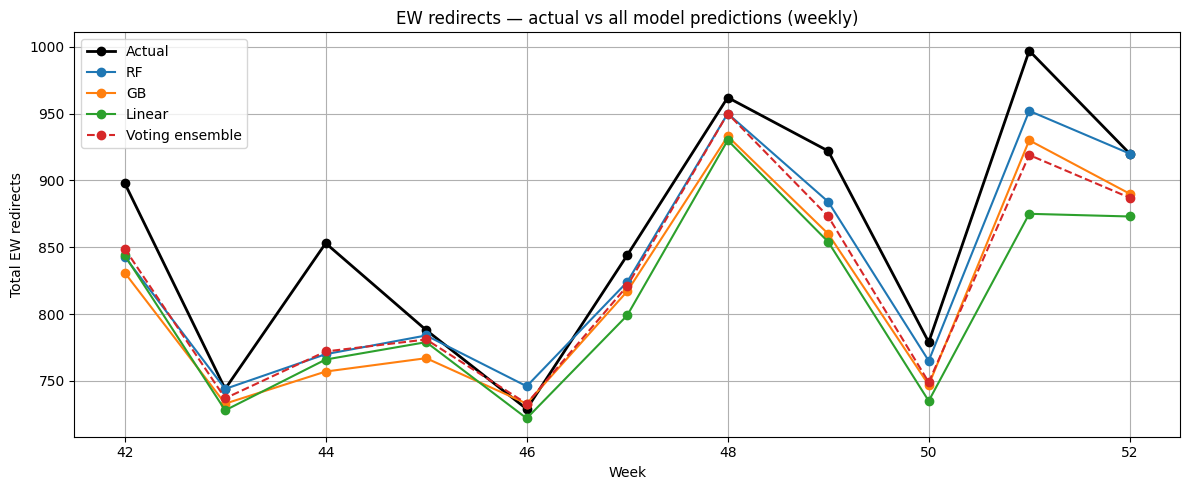

In [34]:
plt.figure(figsize=(12, 5))

plt.plot(
    simple_model6_weekly["WeekNumber"],
    simple_model6_weekly["Actual"],
    "o-", linewidth=2, label="Actual", color="black"
)
plt.plot(simple_model6_weekly["WeekNumber"], simple_model6_weekly["Pred_RF"], "o-", label="RF")
plt.plot(simple_model6_weekly["WeekNumber"], simple_model6_weekly["Pred_GB"], "o-", label="GB")
plt.plot(simple_model6_weekly["WeekNumber"], simple_model6_weekly["Pred_LR"], "o-", label="Linear")
plt.plot(
    simple_model6_weekly["WeekNumber"],
    simple_model6_weekly["Pred_Voting"],
    "o--", linewidth=1.5, label="Voting ensemble"
)

plt.xlabel("Week")
plt.ylabel("Total EW redirects")
plt.title("EW redirects — actual vs all model predictions (weekly)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Top 20 RF features (grouped):
                    raw_feature  importance
                    UserCountry    0.407614
                      EW_Gap_vs    0.090056
                    EW_Ratio_vs    0.078781
                 BookingHorizon    0.059915
                 NumberOfNights    0.041674
           AvgCompetitorRevenue    0.040092
      CheapestCompetitorRevenue    0.032148
                     CabinClass    0.031745
AvgLowest50PctCompetitorRevenue    0.031628
                        WeekCos    0.028034
                     WeekNumber    0.024455
                        WeekSin    0.023035
             DestinationAirport    0.019617
                  OriginAirport    0.018522
             DestinationCountry    0.013760
                CountryRoute_DE    0.008695
                       TripType    0.006707
           CompetitorOfferCount    0.006209
         CompetitorAirlineCount    0.005036
                  OriginCountry    0.004763


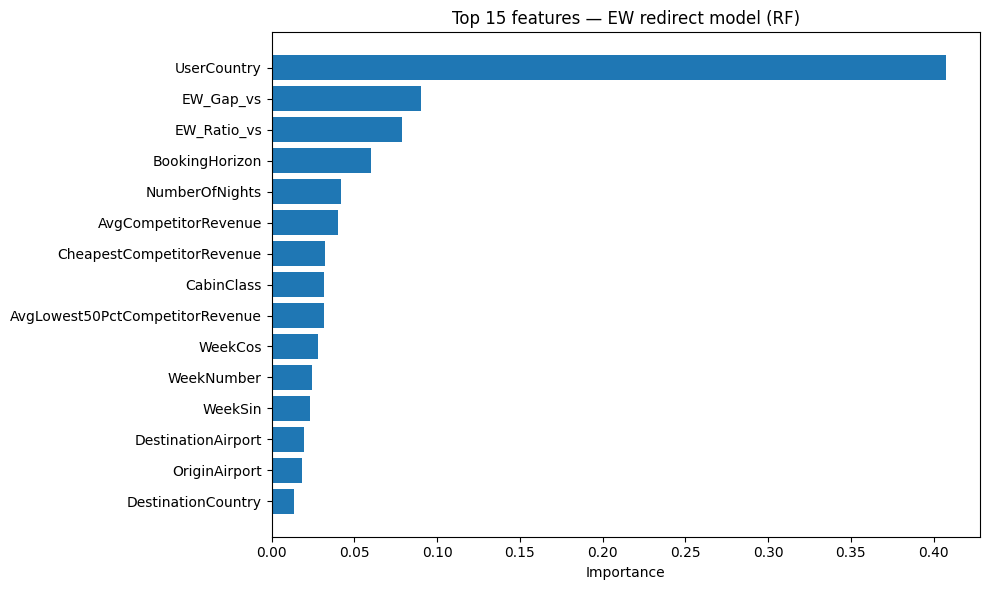

In [37]:
# ============================================================
# BONUS: Feature importance — Simple Model 6 (RF)
# ============================================================

preprocess = simple_model6_voting_pipe.named_steps["preprocess"]
rf_model = simple_model6_voting_pipe.named_steps["ensemble"].named_estimators_["rf"]

feature_names = preprocess.get_feature_names_out()
importances = rf_model.feature_importances_

redirect_rf_importance = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

# group one-hot columns back to raw feature name
def to_raw_feature_name(name):
    name = name.replace("num__", "").replace("cat__", "")
    if "_" in name:
        parts = name.rsplit("_", 1)
        # keep full name if last part doesn't look like a category level
        if len(parts) == 2 and parts[1] not in parts[0]:
            return parts[0]
    return name

redirect_rf_importance["raw_feature"] = redirect_rf_importance["feature"].apply(to_raw_feature_name)

redirect_rf_importance_grouped = (
    redirect_rf_importance
    .groupby("raw_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 RF features (grouped):")
print(redirect_rf_importance_grouped.head(20).to_string(index=False))

# plot
top_n = 15
top = redirect_rf_importance_grouped.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top["raw_feature"][::-1], top["importance"][::-1])
plt.xlabel("Importance")
plt.title(f"Top {top_n} features — EW redirect model (RF)")
plt.tight_layout()
plt.show()

# optional save
redirect_rf_importance_grouped.to_csv(
    "bonus_redirect_rf_feature_importance_grouped.csv", index=False
)

# Number of Redirect Conclusion

Goal: Predict Eurowings redirects (NumberOfRedirects) on EW-only rows — how many bookings/redirects EW gets per search segment.

Setup: Train W01–W41, test W42–W52 (same as main price model). Added competitor market features (cheapest/avg prices, offer counts, EW price gaps vs competitors).

Price inputs: Train weeks use actual competitor fares; test weeks use predicted fares from our main ensemble price model — avoids leakage and mimics real forecasting.

Model: Simple Model 6 — row-level VotingRegressor with RF + Gradient Boosting + Linear Regression; predictions rounded to whole numbers (redirects are counts).

Row-level results: All models ~MAE 1.44–1.51 redirects per row; GB slightly best (~1.44), but R² only ~0.22 — hard to explain each row because redirects vary a lot (0–14).

Weekly results: We sum row predictions by week; RF is best (~MAE 27, R² 0.82) — much stronger than row-level because errors cancel when aggregated.

Choice: Use RF weekly totals as the business forecast; skip voting ensemble for weekly (it did not beat RF). Row-level GB is optional detail only.

Takeaway: Redirect demand follows competitor pricing + route/week context; chaining price model → redirect model works well for weekly planning, even if individual rows stay noisy.

# Final Thoughts

## Methodology

Engineered Route, CountryRoute, WeekSin, WeekCos — seasonality as a cycle, not just week ID.

Used log revenue for competitor prices; report MAE back in €.

Train W01–W41 / test W42–W52 — forward split, no overlap.

Log RF: price from cabin, route, carrier, booking context + seasonality.

Holt + Residual RF: Holt = weekly trend; RF = leftover pattern without week columns (no double time modelling).

Ensemble: 31.3% Log RF + 68.7% Holt+Residual — weights tuned in pred3.ipynb, reused in final.

Bonus chain: test-week competitor features from Pred_WeightedEnsemble; train weeks use actual competitor prices.

Bonus features: offer counts, cheapest/avg/lowest-50% competitor price, EW gap/ratio, fallback match levels.

Bonus model: VotingRegressor (RF + GB + Linear) on EW rows; rounded redirect preds; weekly = sum of rows.

# Results

Price ensemble: MAE ~€10.6, weekly R² ~0.88 — beats both single models.

Log RF alone: ~€15.1 — misses weekly trend.

Holt+Residual alone: ~€11.5 — good trend, weaker on row detail.

Price drivers (Log RF): CabinClass, WeekCos, carrier.

Price drivers (Residual RF): CabinClass, carrier — no week cols by design.

Redirect row-level: GB best, MAE ~1.44, R² ~0.22 — ~1 redirect off per row.

Redirect weekly: RF best, MAE ~27, R² ~0.82 — use this for business.

Voting ensemble: does not beat RF on weekly totals.

Redirect drivers: UserCountry (~41%), EW gap/ratio (~17%), booking horizon, nights, cabin, competitor prices.

Overall: decent and usable; weekly metrics strong enough to present.

Overfitting risk: not fully checked — UserCountry, Route, airports may memorize train; no route/CV holdout.

# Results

Competitor price — all models predict row-by-row (one price per segment: week, route, carrier, cabin, etc.). MAE and R² below are row-level on test W42–W52.

Ensemble (best): row MAE ~€10.7, row R² ~0.88 — beats Log RF and Holt+Residual on every row-level metric.

Log RF alone: row MAE ~€15.1, row R² ~0.80 — solid baseline; uses WeekSin/WeekCos for seasonality but still undertracks the late-week revenue drop when you plot mean price by week (chart check, not a different model).

Holt + Residual alone: row MAE ~€11.5, row R² ~0.86 — better than Log RF on rows too (lower MAE, higher R²); Holt carries weekly trend, RF adds route/cabin/carrier detail without week columns.

Why blend: Log RF and Holt+Residual err in different ways; fixed weights 31.3% / 68.7% (from pred3 tuning) shave another ~€0.8 MAE vs Holt alone.

Weekly price chart: optional — mean of row predictions per week vs mean actual; used to visualise trend, not a separate weekly model.

Price drivers — Log RF: CabinClass, WeekCos, MainAirlineCarrier dominate.

Price drivers — Residual RF: CabinClass, carrier; no WeekNumber/WeekSin/WeekCos — Holt already owns time.

EW redirects — row-level: GB best, MAE ~1.44, R² ~0.22 — typically ~1 redirect off per row; counts 0–14 stay hard to explain row-by-row.

EW redirects — weekly: sum rounded row preds by week; RF best, MAE ~27, R² ~0.82 — this is the business forecast (total EW demand per week).

Redirect voting ensemble: does not beat RF on weekly totals — report RF for planning, GB only as row-level note.

Redirect drivers (RF): UserCountry (~41%), EW gap/ratio vs competitors (~17%), then BookingHorizon, NumberOfNights, CabinClass, competitor price features.

Overall read: competitor row pricing is strong (R² ~0.88); redirect weekly is strong (R² ~0.82); redirect row R² is low but MAE is small in count units — fit for case study, not production-sign-off.

Overfitting (not tested): UserCountry, Route, airports have many levels — may fit train noise; no route holdout or CV run, so treat metrics as good but unverified outside time split.

# Results

Competitor price forecast (row-level, R² ~0.88): You can estimate what rivals will charge by week, route, cabin, and carrier — use this to set fares in line with the market, not blind.

Seasonality & cabin matter most for price: Business vs Economy and time of year drive fares — push premium cabins in strong weeks, discount or bundle in weak weeks (W42–W52 dip).

EW redirect forecast (weekly RF, R² ~0.82): You get expected total EW bookings per week — use it for capacity, marketing spend, and revenue planning.

Redirects follow search country & price gap: UserCountry and EW vs competitor price drive redirects — if EW is more expensive than competitors, expect fewer redirects; lower gap or undercut on key routes/countries to win more clicks/bookings.

Action loop: Refresh competitor price forecast → check EW gap → adjust fares on high-traffic routes/countries → track weekly redirects; focus on UserCountry + cabin + competitive price position, not airport-level noise alone.

# Things we can do

Deep neural network — possible, but RF already strong on weekly; trees easier to explain.

SHAP / partial dependence — explain UserCountry and price-gap effects for product/pricing teams.

Hyperparameter tuning — full search done in pred3.ipynb; final only uses fixed best weights (31.3% / 68.7%) — could re-tune on fresh data periodically.

